# Hani 5'UTR Lib2 Phase 2 v2 Fine-Tune Analysis (May 2026)

Downstream analysis for the broad HPO Phase 2 v2 run with fixed splitting.

This notebook intentionally treats `lib2_inner_val` as the HPO screening signal and keeps the untouched `lib2_final_test` out of the screening decision. Final-test cells are gated and only populate after a `STAGE=final_eval` run exists in the same output root.

In [1]:
from __future__ import annotations

import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ModuleNotFoundError:
    def display(obj=None, *args, **kwargs):
        print(obj)

    class Markdown(str):
        pass

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 260)
pd.set_option("display.max_rows", 180)
pd.set_option("display.width", 280)

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

REPO_ROOT = Path("/home/minhang/synBio_AL/boda2_EU")
SWEEP_DIR = REPO_ROOT / "src/finetune/learning_curve/hani_utr5_lib2_resnet1d_1mmy39ku_phase2_v2_may2026"
COMBINED_DIR = SWEEP_DIR / "combined"
SPLIT_DIR = SWEEP_DIR / "split_manifests"
NOTEBOOK_DIR = REPO_ROOT / "tutorials/lib1_tasks/fine_tuning/fivePrime_finetune_w_lib1_hani_pretrain"
PLOT_DIR = NOTEBOOK_DIR / "plots/hani_utr5_lib2_phase2_v2_may2026"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_LABEL = "pretrained_1mmy39ku"
HEAD_ORDER = ["c1", "c2", "c4", "c6", "c17"]
HEAD_LABELS = {
    "c1": "c1 MDA-MB-231",
    "c2": "c2 HepG2",
    "c4": "c4 Jurkat",
    "c6": "c6 SW480",
    "c17": "c17 NALM6",
}
SCOPE_ORDER = ["head_only", "last_stage_plus_head", "full"]
SCREENING_SPLITS = ["lib2_inner_val", "lib1_test_retention"]
EPOCH_SPLIT_ORDER = ["train", "val", "test", "test_inhouse", "test_inhouse_all"]
CONFIG_COLS = [
    "unfreeze_scope",
    "head_lr",
    "backbone_lr",
    "target_scaler_source",
    "freeze_backbone_epochs",
    "weight_decay",
]
METRIC_COLS = [
    "average_activity_pearson",
    "mean_per_head_pearson",
    "flattened_activity_pearson",
    "average_activity_spearman",
    "average_activity_rmse",
]

SCOPE_PALETTE = {
    "head_only": "#0072B2",
    "last_stage_plus_head": "#009E73",
    "full": "#D55E00",
}
SPLIT_PALETTE = {
    "train": "#0072B2",
    "val": "#E69F00",
    "test": "#CC79A7",
    "test_inhouse": "#009E73",
    "test_inhouse_all": "#56B4E9",
}

CSV_PATHS = {
    "summary": COMBINED_DIR / "model_comparison_summary.csv",
    "ranking": COMBINED_DIR / "lib2_validation_model_ranking.csv",
    "final_ranking": COMBINED_DIR / "lib2_final_test_model_ranking.csv",
    "per_head": COMBINED_DIR / "per_head_metrics.csv",
    "inhouse": COMBINED_DIR / "inhouse_fiveprime_metrics.csv",
    "epoch": COMBINED_DIR / "per_epoch_diagnostics.csv",
    "split_audit": COMBINED_DIR / "split_audit.csv",
    "outer_manifest": COMBINED_DIR / "outer_final_test_manifest.csv",
    "split_policy": COMBINED_DIR / "split_policy.json",
}

print("SWEEP_DIR:", SWEEP_DIR)
print("COMBINED_DIR:", COMBINED_DIR)
print("PLOT_DIR:", PLOT_DIR)

SWEEP_DIR: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/hani_utr5_lib2_resnet1d_1mmy39ku_phase2_v2_may2026
COMBINED_DIR: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/hani_utr5_lib2_resnet1d_1mmy39ku_phase2_v2_may2026/combined
PLOT_DIR: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/fine_tuning/fivePrime_finetune_w_lib1_hani_pretrain/plots/hani_utr5_lib2_phase2_v2_may2026


## Load Combined Outputs

In [2]:
def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def read_csv_optional(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def read_json_optional(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open() as handle:
        return json.load(handle)


def compact_values(values, max_items: int = 14, precision: int = 4) -> str:
    series = pd.Series(values).dropna().drop_duplicates()
    if series.empty:
        return ""
    try:
        series = series.sort_values()
    except TypeError:
        pass
    out = []
    for value in series.iloc[:max_items]:
        if isinstance(value, (float, np.floating)) and float(value).is_integer():
            out.append(str(int(value)))
        elif isinstance(value, (float, np.floating)):
            out.append(f"{float(value):.{precision}g}")
        else:
            out.append(str(value))
    if len(series) > max_items:
        out.append(f"... +{len(series) - max_items}")
    return ", ".join(out)


def lr_label(value) -> str:
    if pd.isna(value):
        return "pretrained"
    return f"{float(value):.0e}"


def standard_error(values) -> float:
    vals = pd.to_numeric(pd.Series(values), errors="coerce").dropna().astype(float)
    if len(vals) <= 1:
        return np.nan
    return float(vals.std(ddof=1) / math.sqrt(len(vals)))


def add_common_columns(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if out.empty:
        return out
    if "model_label" in out.columns:
        out["model_family"] = np.where(out["model_label"].eq(BASELINE_LABEL), "pretrained", "finetuned")
    if "unfreeze_scope" in out.columns:
        out["unfreeze_scope"] = pd.Categorical(out["unfreeze_scope"], categories=SCOPE_ORDER, ordered=True)
    if "head" in out.columns:
        out["head"] = pd.Categorical(out["head"], categories=HEAD_ORDER, ordered=True)
        out["head_label"] = out["head"].astype(str).map(HEAD_LABELS)
    for col in ["head_lr", "backbone_lr", "weight_decay"]:
        if col in out.columns:
            out[f"{col}_label"] = out[col].map(lr_label)
    if "freeze_backbone_epochs" in out.columns:
        out["freeze_label"] = out["freeze_backbone_epochs"].map(lambda x: "pretrained" if pd.isna(x) else f"freeze={int(x)}")
    if set(CONFIG_COLS).issubset(out.columns):
        out["config_label"] = np.where(
            out.get("model_family", pd.Series(index=out.index, dtype=object)).eq("pretrained") if "model_family" in out.columns else False,
            "pretrained",
            out["unfreeze_scope"].astype(str)
            + " | hlr=" + out["head_lr"].map(lr_label).astype(str)
            + " | blr=" + out["backbone_lr"].map(lr_label).astype(str)
            + " | scaler=" + out["target_scaler_source"].astype(str)
            + " | freeze=" + out["freeze_backbone_epochs"].map(lambda x: "NA" if pd.isna(x) else str(int(x))).astype(str)
            + " | wd=" + out["weight_decay"].map(lr_label).astype(str),
        )
    return out


def load_fit_info_records() -> pd.DataFrame:
    rows = []
    for path in sorted((SWEEP_DIR / "per_job").glob("*/*/training_seed_*/runs/*/fit_info.json")):
        payload = read_json_optional(path)
        if not payload:
            continue
        row = {
            key: payload.get(key)
            for key in [
                "stage", "split_id", "outer_split_seed", "inner_split_seed", "training_seed", "run_seed",
                "unfreeze_scope", "head_lr", "backbone_lr", "target_scaler_source",
                "freeze_backbone_epochs", "weight_decay", "best_epoch", "best_monitor_value",
                "monitor_metric", "monitor_mode", "max_epochs", "min_epochs", "patience", "use_early_stopping",
            ]
        }
        row["run_dir"] = str(path.parent)
        row["run_tag"] = path.parent.name
        row["model_label"] = f"finetuned_1mmy39ku__{path.parent.name}"
        rows.append(row)
    return add_common_columns(pd.DataFrame(rows))


summary = add_common_columns(read_csv_required(CSV_PATHS["summary"]).drop_duplicates())
ranking = add_common_columns(read_csv_optional(CSV_PATHS["ranking"]).drop_duplicates())
final_ranking = add_common_columns(read_csv_optional(CSV_PATHS["final_ranking"]).drop_duplicates())
per_head = add_common_columns(read_csv_required(CSV_PATHS["per_head"]).drop_duplicates())
inhouse = add_common_columns(read_csv_required(CSV_PATHS["inhouse"]).drop_duplicates())
epoch_diag = add_common_columns(read_csv_required(CSV_PATHS["epoch"]).drop_duplicates())
split_audit = read_csv_required(CSV_PATHS["split_audit"])
outer_manifest = read_csv_required(CSV_PATHS["outer_manifest"])
split_policy = read_json_optional(CSV_PATHS["split_policy"])
fit_info = load_fit_info_records()

inner_manifests = {
    path.stem.replace("inner_split_manifest_", ""): read_csv_required(path)
    for path in sorted(COMBINED_DIR.glob("inner_split_manifest_*.csv"))
}

print("summary:", summary.shape)
print("per_head:", per_head.shape)
print("inhouse:", inhouse.shape)
print("epoch_diag:", epoch_diag.shape)
print("fit_info:", fit_info.shape)
print("inner manifests:", list(inner_manifests))

summary: (438, 32)
per_head: (2190, 31)
inhouse: (5256, 30)
epoch_diag: (736660, 37)
fit_info: (216, 29)
inner manifests: ['inner0_seed_101', 'inner1_seed_202', 'inner2_seed_303']


In [3]:
summary

,model_label,split,run_seed,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,stage,outer_split_seed,inner_split_seed,training_seed,split_id,freeze_backbone_epochs,weight_decay,n_sequences,n_heads,heads_used,mean_per_head_pearson,mean_per_head_pearson_r2,flattened_activity_pearson,flattened_activity_pearson_r2,average_activity_pearson,average_activity_pearson_r2,average_activity_spearman,average_activity_mae,average_activity_rmse,model_family,head_lr_label,backbone_lr_label,weight_decay_label,freeze_label,config_label
0,pretrained_1mmy39ku,lib2_inner_val,NaN,NaN,NaN,NaN,pretrained_lib1_train,screening,20260526,101,NaN,inner0_seed_101,NaN,NaN,916,5,"c1,c2,c4,c6,c17",0.556055,0.309197,0.541032,0.292715,0.733414,0.537897,0.606297,0.109150,0.139069,pretrained,pretrained,pretrained,pretrained,pretrained,pretrained
1,pretrained_1mmy39ku,lib1_test_retention,NaN,NaN,NaN,NaN,pretrained_lib1_train,screening,20260526,101,NaN,inner0_seed_101,NaN,NaN,2160,5,"c1,c2,c4,c6,c17",0.754957,0.569961,0.749670,0.562005,0.833088,0.694035,0.761612,0.066236,0.089315,pretrained,pretrained,pretrained,pretrained,pretrained,pretrained
2,finetuned_1mmy39ku__screening__inner0_seed_101...,lib2_inner_val,7.0,last_stage_plus_head,0.0001,0.000003,pretrained_lib1_train,screening,20260526,101,7.0,inner0_seed_101,0.0,0.0001,916,5,"c1,c2,c4,c6,c17",0.615301,0.378596,0.626172,0.392091,0.794252,0.630836,0.707414,0.074135,0.094866,finetuned,1e-04,3e-06,1e-04,freeze=0,last_stage_plus_head | hlr=1e-04 | blr=3e-06 |...
3,finetuned_1mmy39ku__screening__inner0_seed_101...,lib1_test_retention,7.0,last_stage_plus_head,0.0001,0.000003,pretrained_lib1_train,screening,20260526,101,7.0,inner0_seed_101,0.0,0.0001,2160,5,"c1,c2,c4,c6,c17",0.739575,0.546971,0.707779,0.500951,0.824211,0.679324,0.746004,0.076899,0.098280,finetuned,1e-04,3e-06,1e-04,freeze=0,last_stage_plus_head | hlr=1e-04 | blr=3e-06 |...
4,finetuned_1mmy39ku__screening__inner0_seed_101...,lib2_inner_val,7.0,last_stage_plus_head,0.0001,0.000003,pretrained_lib1_train,screening,20260526,101,7.0,inner0_seed_101,3.0,0.0001,916,5,"c1,c2,c4,c6,c17",0.615340,0.378643,0.626302,0.392255,0.794271,0.630867,0.707460,0.074148,0.094873,finetuned,1e-04,3e-06,1e-04,freeze=3,last_stage_plus_head | hlr=1e-04 | blr=3e-06 |...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,finetuned_1mmy39ku__screening__inner2_seed_303...,lib1_test_retention,7.0,full,0.0003,0.000030,lib2_train,screening,20260526,303,7.0,inner2_seed_303,0.0,0.0001,2160,5,"c1,c2,c4,c6,c17",0.734617,0.539662,0.706209,0.498731,0.817299,0.667977,0.741734,0.073163,0.095006,finetuned,3e-04,3e-05,1e-04,freeze=0,full | hlr=3e-04 | blr=3e-05 | scaler=lib2_tra...
434,finetuned_1mmy39ku__screening__inner2_seed_303...,lib2_inner_val,7.0,full,0.0003,0.000030,lib2_train,screening,20260526,303,7.0,inner2_seed_303,3.0,0.0001,916,5,"c1,c2,c4,c6,c17",0.589709,0.347757,0.596955,0.356356,0.745758,0.556154,0.707271,0.076834,0.102633,finetuned,3e-04,3e-05,1e-04,freeze=3,full | hlr=3e-04 | blr=3e-05 | scaler=lib2_tra...
435,finetuned_1mmy39ku__screening__inner2_seed_303...,lib1_test_retention,7.0,full,0.0003,0.000030,lib2_train,screening,20260526,303,7.0,inner2_seed_303,3.0,0.0001,2160,5,"c1,c2,c4,c6,c17",0.734960,0.540167,0.706322,0.498890,0.817271,0.667932,0.742185,0.073142,0.094937,finetuned,3e-04,3e-05,1e-04,freeze=3,full | hlr=3e-04 | blr=3e-05 | scaler=lib2_tra...
436,finetuned_1mmy39ku__screening__inner2_seed_303...,lib2_inner_val,7.0,full,0.0003,0.000030,lib2_train,screening,20260526,303,7.0,inner2_seed_303,5.0,0.0001,916,5,"c1,c2,c4,c6,c17",0.589765,0.347823,0.596935,0.356331,0.745864,0.556312,0.707472,0.076782,0.102598,finetuned,3e-04,3e-05,1e-04,freeze=5,full | hlr=3e-04 | blr=3e-05 | scaler=lib2_tra...


## Run and Split Audit

In [4]:
stage_counts = (
    summary.groupby(["stage", "split", "model_family"], observed=True)
    .size()
    .rename("rows")
    .reset_index()
)

outer_counts = outer_manifest["outer_split"].value_counts().to_dict()
inner_counts = pd.concat(
    [df.assign(split_id=split_id) for split_id, df in inner_manifests.items()],
    ignore_index=True,
) if inner_manifests else pd.DataFrame()

overview = pd.DataFrame([
    {
        "phase": "phase2_v2",
        "stages present": compact_values(summary["stage"]),
        "splits present": compact_values(summary["split"]),
        "outer_split_seed": split_policy.get("outer_split_seed"),
        "inner_split_seeds": compact_values(split_policy.get("inner_split_seeds", [])),
        "final_test_frac": split_policy.get("final_test_frac"),
        "inner_val_frac": split_policy.get("inner_val_frac"),
        "hpo_pool sequences": outer_counts.get("hpo_pool"),
        "final_test sequences": outer_counts.get("final_test"),
        "finetuned configs": summary.loc[summary["model_family"].eq("finetuned"), CONFIG_COLS].drop_duplicates().shape[0],
        "split ids": compact_values(summary["split_id"]),
        "training seeds": compact_values(summary["training_seed"]),
        "monitor": compact_values(fit_info["monitor_metric"] if not fit_info.empty else []),
    }
])

display(overview)
display(Markdown("Rows present in the combined metric table."))
display(stage_counts)

display(Markdown("Split policy."))
display(pd.DataFrame([split_policy]))

display(Markdown("Split audit written by the training script."))
display(split_audit.round(5))

if not inner_counts.empty:
    display(Markdown("Inner split counts."))
    display(inner_counts.groupby(["split_id", "split"]).size().rename("n_sequences").reset_index())

completion = (
    summary.loc[(summary["model_family"].eq("finetuned")) & (summary["split"].eq("lib2_inner_val"))]
    .groupby(CONFIG_COLS, observed=True)
    .agg(
        n_split_ids=("split_id", "nunique"),
        split_ids=("split_id", compact_values),
        n_training_seeds=("training_seed", "nunique"),
        n_rows=("model_label", "size"),
    )
    .reset_index()
    .sort_values(["n_split_ids", "n_rows"], ascending=[True, True])
)

display(Markdown("Config completeness. Screening should normally have 3 split IDs and 1 training seed per split."))
display(completion.head(20))

,phase,stages present,splits present,outer_split_seed,inner_split_seeds,final_test_frac,inner_val_frac,hpo_pool sequences,final_test sequences,finetuned configs,split ids,training seeds,monitor
0,phase2_v2,screening,"lib1_test_retention, lib2_inner_val",20260526,"101, 202, 303",0.1,0.1,9157,1017,72,"inner0_seed_101, inner1_seed_202, inner2_seed_303",7,val_average_activity_pearson


Rows present in the combined metric table.

,stage,split,model_family,rows
0,screening,lib1_test_retention,finetuned,216
1,screening,lib1_test_retention,pretrained,3
2,screening,lib2_inner_val,finetuned,216
3,screening,lib2_inner_val,pretrained,3


Split policy.

,activity_quantile_bins,final_test_frac,final_test_usage_policy,gc_quantile_bins,inner_split_seeds,inner_val_frac,outer_split_seed,split_unit,stratification_variables,version
0,5,0.1,Final-test rows are excluded from screening an...,5,"[101, 202, 303]",0.1,20260526,unique uppercased exact 50-nt sequence,"[average_activity, gc_fraction]",phase2_v2


...

,split,n_sequences,gc_mean,gc_std,avg_activity_mean,avg_activity_std,c1_mean,c1_std,c2_mean,c2_std,c4_mean,c4_std,c6_mean,c6_std,c17_mean,c17_std,level,split_id,inner_split_seed
0,final_test,1017,0.70238,0.09377,2.49812,0.15083,2.50106,0.13963,2.50407,0.14542,2.49226,0.23323,2.48837,0.23056,2.50484,0.25910,outer,outer,NaN
1,hpo_pool,9157,0.70245,0.09493,2.49768,0.15084,2.50351,0.14176,2.49827,0.14596,2.49184,0.24314,2.49438,0.23243,2.50039,0.25829,outer,outer,NaN
2,train,8241,0.70241,0.09484,2.49783,0.15032,2.50335,0.14147,2.49787,0.14504,2.49233,0.24135,2.49443,0.23228,2.50116,0.25731,inner,inner0_seed_101,101.0
3,val,916,0.70282,0.09574,2.49631,0.15547,2.50490,0.14442,2.50185,0.15399,2.48740,0.25877,2.49385,0.23390,2.49354,0.26691,inner,inner0_seed_101,101.0
4,train,8241,0.70235,0.09476,2.49783,0.15061,2.50389,0.14166,2.49814,0.14616,2.49166,0.24264,2.49404,0.23236,2.50140,0.25865,inner,inner1_seed_202,202.0
5,val,916,0.70336,0.09646,2.49632,0.15300,2.50002,0.14267,2.49942,0.14416,2.49346,0.24774,2.49739,0.23315,2.49131,0.25497,inner,inner1_seed_202,202.0
6,train,8241,0.70249,0.09498,2.49777,0.15049,2.50274,0.14150,2.49874,0.14486,2.49184,0.24241,2.49413,0.23239,2.50139,0.25836,inner,inner2_seed_303,303.0
7,val,916,0.70218,0.09453,2.49688,0.15400,2.51042,0.14399,2.49408,0.15554,2.49185,0.24976,2.49658,0.23285,2.49147,0.25758,inner,inner2_seed_303,303.0


Inner split counts.

,split_id,split,n_sequences
0,inner0_seed_101,train,8241
1,inner0_seed_101,val,916
2,inner1_seed_202,train,8241
3,inner1_seed_202,val,916
4,inner2_seed_303,train,8241
5,inner2_seed_303,val,916


Config completeness. Screening should normally have 3 split IDs and 1 training seed per split.

,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,n_split_ids,split_ids,n_training_seeds,n_rows
0,last_stage_plus_head,0.0001,0.000003,lib2_train,0.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
1,last_stage_plus_head,0.0001,0.000003,lib2_train,3.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
2,last_stage_plus_head,0.0001,0.000003,lib2_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
3,last_stage_plus_head,0.0001,0.000003,pretrained_lib1_train,0.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
4,last_stage_plus_head,0.0001,0.000003,pretrained_lib1_train,3.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
5,last_stage_plus_head,0.0001,0.000003,pretrained_lib1_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
6,last_stage_plus_head,0.0001,0.000010,lib2_train,0.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
7,last_stage_plus_head,0.0001,0.000010,lib2_train,3.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
8,last_stage_plus_head,0.0001,0.000010,lib2_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3
9,last_stage_plus_head,0.0001,0.000010,pretrained_lib1_train,0.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",1,3


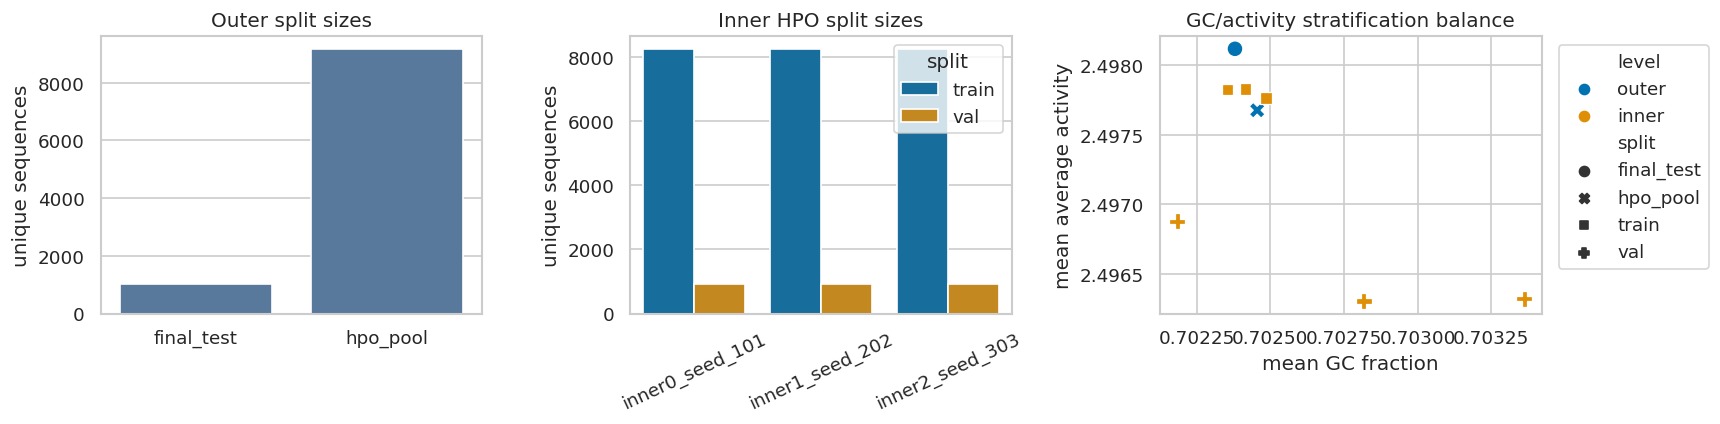

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.7))
outer_plot = (
    split_audit.loc[split_audit["level"].eq("outer")]
    .copy()
    .sort_values("split")
)
sns.barplot(data=outer_plot, x="split", y="n_sequences", ax=axes[0], color="#4C78A8")
axes[0].set_title("Outer split sizes")
axes[0].set_xlabel("")
axes[0].set_ylabel("unique sequences")

inner_plot = split_audit.loc[split_audit["level"].eq("inner")].copy()
sns.barplot(data=inner_plot, x="split_id", y="n_sequences", hue="split", ax=axes[1])
axes[1].set_title("Inner HPO split sizes")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylabel("unique sequences")

sns.scatterplot(
    data=split_audit,
    x="gc_mean",
    y="avg_activity_mean",
    hue="level",
    style="split",
    s=90,
    ax=axes[2],
)
axes[2].set_title("GC/activity stratification balance")
axes[2].set_xlabel("mean GC fraction")
axes[2].set_ylabel("mean average activity")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOT_DIR / "phase2_v2_split_audit.png", bbox_inches="tight")
plt.show()

## Screening HPO Leaderboard

The primary ranking signal is mean `lib2_inner_val` average-activity Pearson across inner split IDs. Lib1 retention is kept beside it as a promotion gate, not as a final-test substitute.

In [6]:
def aggregate_summary_by_config(frame: pd.DataFrame, split: str, prefix: str) -> pd.DataFrame:
    sub = frame.loc[(frame["model_family"].eq("finetuned")) & (frame["split"].eq(split))].copy()
    if sub.empty:
        return pd.DataFrame()
    out = (
        sub.groupby(CONFIG_COLS, observed=True)
        .agg(
            n_rows=("model_label", "size"),
            n_split_ids=("split_id", "nunique"),
            split_ids=("split_id", compact_values),
            n_training_seeds=("training_seed", "nunique"),
            avg_r_mean=("average_activity_pearson", "mean"),
            avg_r_std=("average_activity_pearson", "std"),
            avg_r_se=("average_activity_pearson", standard_error),
            avg_r_min=("average_activity_pearson", "min"),
            mean_head_r_mean=("mean_per_head_pearson", "mean"),
            mean_head_r_se=("mean_per_head_pearson", standard_error),
            flat_r_mean=("flattened_activity_pearson", "mean"),
            avg_spearman_mean=("average_activity_spearman", "mean"),
            avg_rmse_mean=("average_activity_rmse", "mean"),
        )
        .reset_index()
    )
    rename = {col: f"{prefix}_{col}" for col in out.columns if col not in CONFIG_COLS}
    return out.rename(columns=rename)


inner_val_config = aggregate_summary_by_config(summary, "lib2_inner_val", "inner_val")
lib1_config = aggregate_summary_by_config(summary, "lib1_test_retention", "lib1_retention")

baseline_inner = (
    summary.loc[(summary["model_label"].eq(BASELINE_LABEL)) & (summary["split"].eq("lib2_inner_val"))]
    .drop_duplicates(["split_id", "model_label"])
)
baseline_lib1 = (
    summary.loc[(summary["model_label"].eq(BASELINE_LABEL)) & (summary["split"].eq("lib1_test_retention"))]
    .drop_duplicates(["split_id", "model_label"])
)

leaderboard = inner_val_config.merge(lib1_config, on=CONFIG_COLS, how="left")
leaderboard["delta_inner_val_avg_r_vs_pretrained_mean"] = (
    leaderboard["inner_val_avg_r_mean"] - baseline_inner["average_activity_pearson"].mean()
)
leaderboard["delta_lib1_retention_avg_r_vs_pretrained_mean"] = (
    leaderboard["lib1_retention_avg_r_mean"] - baseline_lib1["average_activity_pearson"].mean()
)
leaderboard = add_common_columns(leaderboard)
leaderboard = leaderboard.sort_values(
    ["inner_val_avg_r_mean", "lib1_retention_avg_r_mean", "inner_val_avg_r_min"],
    ascending=[False, False, False],
).reset_index(drop=True)
leaderboard.insert(0, "screening_rank", np.arange(1, len(leaderboard) + 1))

selected_config = leaderboard.iloc[0].to_dict()
selected_config_mask = np.ones(len(summary), dtype=bool)
for col in CONFIG_COLS:
    if pd.api.types.is_numeric_dtype(summary[col]):
        selected_config_mask &= np.isclose(pd.to_numeric(summary[col], errors="coerce"), float(selected_config[col]))
    else:
        selected_config_mask &= summary[col].astype(str).eq(str(selected_config[col]))

inner_checkpoint_ranking = (
    summary.loc[(summary["model_family"].eq("finetuned")) & (summary["split"].eq("lib2_inner_val"))]
    .sort_values(["average_activity_pearson", "mean_per_head_pearson"], ascending=[False, False])
    .reset_index(drop=True)
)
selected_checkpoint = inner_checkpoint_ranking.iloc[0].to_dict()
selected_label = selected_checkpoint["model_label"]
selected_split_id = selected_checkpoint["split_id"]
selected_training_seed = int(selected_checkpoint["training_seed"])

display(Markdown("Screening config leaderboard. Top row is the current config-level HPO choice."))
leaderboard_cols = [
    "screening_rank", *CONFIG_COLS, "inner_val_n_split_ids", "inner_val_split_ids",
    "inner_val_avg_r_mean", "inner_val_avg_r_se", "inner_val_avg_r_min",
    "inner_val_mean_head_r_mean", "inner_val_flat_r_mean",
    "lib1_retention_avg_r_mean", "lib1_retention_mean_head_r_mean",
    "delta_inner_val_avg_r_vs_pretrained_mean", "delta_lib1_retention_avg_r_vs_pretrained_mean",
]
display(leaderboard[leaderboard_cols].head(25).round(5))
leaderboard.to_csv(PLOT_DIR / "phase2_v2_screening_config_leaderboard.csv", index=False)

checkpoint_cols = [
    "model_label", "split_id", "training_seed", *CONFIG_COLS,
    "average_activity_pearson", "mean_per_head_pearson", "flattened_activity_pearson", "average_activity_spearman", "average_activity_rmse",
]
display(Markdown("Top individual inner-validation checkpoints. Useful for prediction scatter inspection only."))
display(inner_checkpoint_ranking[checkpoint_cols].head(12).round(5))

print("Selected config:")
for col in CONFIG_COLS:
    print(f"  {col}: {selected_config[col]}")
print("Selected individual checkpoint:", selected_label)

Screening config leaderboard. Top row is the current config-level HPO choice.

,screening_rank,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,inner_val_n_split_ids,inner_val_split_ids,inner_val_avg_r_mean,inner_val_avg_r_se,inner_val_avg_r_min,inner_val_mean_head_r_mean,inner_val_flat_r_mean,lib1_retention_avg_r_mean,lib1_retention_mean_head_r_mean,delta_inner_val_avg_r_vs_pretrained_mean,delta_lib1_retention_avg_r_vs_pretrained_mean
0,1,full,0.0003,0.00001,pretrained_lib1_train,0.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78271,0.01994,0.74770,0.61515,0.62475,0.81842,0.73504,0.07653,-0.01467
1,2,full,0.0003,0.00001,lib2_train,3.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78268,0.02015,0.74750,0.61625,0.62495,0.81763,0.73439,0.07651,-0.01545
2,3,full,0.0003,0.00001,lib2_train,0.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78265,0.02035,0.74724,0.61577,0.62459,0.81803,0.73484,0.07648,-0.01505
3,4,full,0.0003,0.00001,lib2_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78261,0.02019,0.74713,0.61594,0.62452,0.81843,0.73484,0.07644,-0.01466
4,5,full,0.0003,0.00001,pretrained_lib1_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78258,0.02013,0.74712,0.61494,0.62467,0.81831,0.73524,0.07641,-0.01478
5,6,full,0.0003,0.00001,pretrained_lib1_train,3.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78254,0.02019,0.74715,0.61524,0.62490,0.81724,0.73424,0.07637,-0.01585
6,7,full,0.0003,0.00003,pretrained_lib1_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78144,0.01984,0.74615,0.61345,0.62300,0.81667,0.73473,0.07526,-0.01641
7,8,full,0.0003,0.00000,pretrained_lib1_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78134,0.01855,0.74716,0.61320,0.62283,0.82156,0.73745,0.07517,-0.01153
8,9,full,0.0003,0.00000,pretrained_lib1_train,3.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78134,0.01855,0.74714,0.61315,0.62302,0.82249,0.73773,0.07517,-0.01059
9,10,full,0.0001,0.00001,lib2_train,5.0,0.0001,3,"inner0_seed_101, inner1_seed_202, inner2_seed_303",0.78133,0.02025,0.74571,0.61421,0.62275,0.81661,0.73411,0.07516,-0.01648


Top individual inner-validation checkpoints. Useful for prediction scatter inspection only.

,model_label,split_id,training_seed,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,average_activity_pearson,mean_per_head_pearson,flattened_activity_pearson,average_activity_spearman,average_activity_rmse
0,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00001,lib2_train,0.0,0.0001,0.81774,0.63759,0.64914,0.74273,0.08966
1,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00001,lib2_train,3.0,0.0001,0.81728,0.63796,0.64886,0.74213,0.09014
2,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00001,pretrained_lib1_train,3.0,0.0001,0.81706,0.63658,0.64873,0.74278,0.08984
3,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00001,lib2_train,5.0,0.0001,0.81705,0.63766,0.64857,0.74177,0.09015
4,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00001,pretrained_lib1_train,5.0,0.0001,0.81683,0.63655,0.64864,0.74295,0.08989
5,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00001,pretrained_lib1_train,0.0,0.0001,0.81677,0.63655,0.64821,0.74172,0.09019
6,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00003,lib2_train,5.0,0.0001,0.81586,0.63569,0.64591,0.74168,0.09003
7,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0003,0.00003,lib2_train,3.0,0.0001,0.81582,0.63591,0.64597,0.74213,0.09004
8,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0001,0.00001,lib2_train,5.0,0.0001,0.81581,0.63435,0.64569,0.74081,0.09003
9,finetuned_1mmy39ku__screening__inner0_seed_101...,inner0_seed_101,7.0,full,0.0001,0.00001,lib2_train,3.0,0.0001,0.81564,0.63439,0.64570,0.74044,0.09006


Selected config:
  unfreeze_scope: full
  head_lr: 0.0003
  backbone_lr: 1e-05
  target_scaler_source: pretrained_lib1_train
  freeze_backbone_epochs: 0.0
  weight_decay: 0.0001
Selected individual checkpoint: finetuned_1mmy39ku__screening__inner0_seed_101__outer20260526__inner101__seed7__full__hlr3p0e04__blr1p0e05__scaler_lib2_train__freeze0__wd1p0e04


## Multi-Metric HPO Diagnostics

COD R2 and RMSE are raw-scale metrics, so they can improve when fine-tuning mostly fixes numeric calibration. Pearson and Spearman test whether rank/order structure improves. The calibration fit below regresses true average activity on predicted average activity; ideal slope is 1 and ideal intercept is 0.

This section uses `lib2_final_test` only if final-eval rows are present; otherwise it uses `lib2_inner_val` as a screening proxy and keeps final-test untouched.


In [7]:
LIB2_GATE_SPLIT = "lib2_final_test" if summary["split"].eq("lib2_final_test").any() else "lib2_inner_val"
PREDICTION_METRIC_SPLITS = list(dict.fromkeys([LIB2_GATE_SPLIT, "lib1_test_retention"]))

if LIB2_GATE_SPLIT != "lib2_final_test":
    display(Markdown("Using `lib2_inner_val` as the multi-metric screening proxy because no `lib2_final_test` rows are present."))
else:
    display(Markdown("Using `lib2_final_test` for the multi-metric gate. Confirm the HPO choice was frozen before interpreting these numbers."))


def finite_xy(y_true, y_pred):
    true = np.asarray(y_true, dtype=float).reshape(-1)
    pred = np.asarray(y_pred, dtype=float).reshape(-1)
    mask = np.isfinite(true) & np.isfinite(pred)
    return true[mask], pred[mask]


def cod_r2_score(y_true, y_pred) -> float:
    true, pred = finite_xy(y_true, y_pred)
    if len(true) < 2:
        return np.nan
    denom = float(np.sum((true - true.mean()) ** 2))
    if denom <= 0:
        return np.nan
    return float(1.0 - np.sum((true - pred) ** 2) / denom)


def prediction_file_for_row(row: pd.Series) -> Path:
    split_id = str(row["split_id"])
    split_name = str(row["split"])
    model_label = str(row["model_label"])
    seed_glob = "*" if pd.isna(row.get("training_seed")) else str(int(row["training_seed"]))
    if model_label == BASELINE_LABEL:
        candidates = sorted(
            SWEEP_DIR.glob(
                f"per_job/*/{split_id}/training_seed_{seed_glob}/predictions/{model_label}__{split_name}_predictions.csv"
            )
        )
    else:
        candidates = sorted(
            SWEEP_DIR.glob(
                f"per_job/*/{split_id}/training_seed_{seed_glob}/runs/*/predictions/{model_label}__{split_name}_predictions.csv"
            )
        )
    if not candidates:
        raise FileNotFoundError((model_label, split_name, split_id, seed_glob))
    return candidates[0]


def average_activity_prediction_metrics(path: Path):
    frame = pd.read_csv(path, usecols=["true_average_activity", "pred_average_activity"])
    true, pred = finite_xy(frame["true_average_activity"], frame["pred_average_activity"])
    if len(true) < 2:
        return {
            "n": len(true),
            "average_activity_pearson": np.nan,
            "average_activity_spearman": np.nan,
            "average_activity_cod_r2": np.nan,
            "average_activity_rmse": np.nan,
            "calibration_slope_true_on_pred": np.nan,
            "calibration_intercept_true_on_pred": np.nan,
            "prediction_bias": np.nan,
        }
    if np.nanstd(pred) > 1e-12:
        slope, intercept = np.polyfit(pred, true, 1)
    else:
        slope, intercept = np.nan, np.nan
    bias = float(np.mean(pred - true))
    return {
        "n": int(len(true)),
        "average_activity_pearson": float(pd.Series(true).corr(pd.Series(pred), method="pearson")),
        "average_activity_spearman": float(pd.Series(true).corr(pd.Series(pred), method="spearman")),
        "average_activity_cod_r2": cod_r2_score(true, pred),
        "average_activity_rmse": float(np.sqrt(np.mean((true - pred) ** 2))),
        "calibration_slope_true_on_pred": float(slope),
        "calibration_intercept_true_on_pred": float(intercept),
        "calibration_slope_abs_error": float(abs(slope - 1.0)) if np.isfinite(slope) else np.nan,
        "calibration_intercept_abs": float(abs(intercept)) if np.isfinite(intercept) else np.nan,
        "prediction_bias": bias,
        "prediction_bias_abs": abs(bias),
    }


prediction_metric_rows = []
missing_prediction_rows = []
prediction_source_rows = summary.loc[summary["split"].isin(PREDICTION_METRIC_SPLITS)].drop_duplicates(
    ["model_label", "split", "split_id", "training_seed"]
)
for _, row in prediction_source_rows.iterrows():
    try:
        path = prediction_file_for_row(row)
    except FileNotFoundError as exc:
        missing_prediction_rows.append({"model_label": row["model_label"], "split": row["split"], "split_id": row["split_id"], "error": str(exc)})
        continue
    record = {
        "model_label": row["model_label"],
        "split": row["split"],
        "split_id": row["split_id"],
        "training_seed": row["training_seed"],
        "prediction_path": str(path),
    }
    for col in CONFIG_COLS:
        record[col] = row.get(col, np.nan)
    record.update(average_activity_prediction_metrics(path))
    prediction_metric_rows.append(record)

avg_activity_prediction_metrics = add_common_columns(pd.DataFrame(prediction_metric_rows))
avg_activity_prediction_metrics.to_csv(PLOT_DIR / "phase2_v2_average_activity_prediction_diagnostics.csv", index=False)

if missing_prediction_rows:
    display(Markdown("Prediction files missing for some summary rows."))
    display(pd.DataFrame(missing_prediction_rows).head(20))

display(Markdown("Average-activity prediction diagnostics computed from saved prediction CSVs."))
display(
    avg_activity_prediction_metrics.groupby(["split", "model_family"], observed=True)
    .size()
    .rename("rows")
    .reset_index()
)



Using `lib2_inner_val` as the multi-metric screening proxy because no `lib2_final_test` rows are present.

Average-activity prediction diagnostics computed from saved prediction CSVs.

,split,model_family,rows
0,lib1_test_retention,finetuned,216
1,lib1_test_retention,pretrained,3
2,lib2_inner_val,finetuned,216
3,lib2_inner_val,pretrained,3


In [8]:
BASELINE_METRIC_COLS = [
    "average_activity_pearson",
    "average_activity_spearman",
    "average_activity_cod_r2",
    "average_activity_rmse",
    "calibration_slope_abs_error",
    "calibration_intercept_abs",
    "prediction_bias_abs",
]

baseline_avg_metrics = (
    avg_activity_prediction_metrics.loc[avg_activity_prediction_metrics["model_label"].eq(BASELINE_LABEL)]
    .drop_duplicates(["split", "split_id"])
    [["split", "split_id", *BASELINE_METRIC_COLS]]
    .rename(columns={col: f"baseline_{col}" for col in BASELINE_METRIC_COLS})
)

avg_metric_delta = avg_activity_prediction_metrics.loc[avg_activity_prediction_metrics["model_family"].eq("finetuned")].merge(
    baseline_avg_metrics,
    on=["split", "split_id"],
    how="left",
)
for col in ["average_activity_pearson", "average_activity_spearman", "average_activity_cod_r2"]:
    avg_metric_delta[f"delta_{col}"] = avg_metric_delta[col] - avg_metric_delta[f"baseline_{col}"]
for col in ["average_activity_rmse", "calibration_slope_abs_error", "calibration_intercept_abs", "prediction_bias_abs"]:
    avg_metric_delta[f"improvement_{col}"] = avg_metric_delta[f"baseline_{col}"] - avg_metric_delta[col]


def aggregate_avg_metric_delta(frame: pd.DataFrame, split: str, prefix: str) -> pd.DataFrame:
    sub = frame.loc[frame["split"].eq(split)].copy()
    if sub.empty:
        return pd.DataFrame(columns=CONFIG_COLS)
    out = (
        sub.groupby(CONFIG_COLS, observed=True)
        .agg(
            n_split_ids=("split_id", "nunique"),
            split_ids=("split_id", compact_values),
            delta_pearson_mean=("delta_average_activity_pearson", "mean"),
            delta_pearson_se=("delta_average_activity_pearson", standard_error),
            delta_spearman_mean=("delta_average_activity_spearman", "mean"),
            delta_cod_r2_mean=("delta_average_activity_cod_r2", "mean"),
            delta_cod_r2_se=("delta_average_activity_cod_r2", standard_error),
            rmse_improvement_mean=("improvement_average_activity_rmse", "mean"),
            rmse_improvement_se=("improvement_average_activity_rmse", standard_error),
            cal_slope_err_improvement_mean=("improvement_calibration_slope_abs_error", "mean"),
            cal_intercept_abs_improvement_mean=("improvement_calibration_intercept_abs", "mean"),
            bias_abs_improvement_mean=("improvement_prediction_bias_abs", "mean"),
            cod_r2_mean=("average_activity_cod_r2", "mean"),
            rmse_mean=("average_activity_rmse", "mean"),
            pearson_mean=("average_activity_pearson", "mean"),
            spearman_mean=("average_activity_spearman", "mean"),
            cal_slope_mean=("calibration_slope_true_on_pred", "mean"),
            cal_intercept_mean=("calibration_intercept_true_on_pred", "mean"),
            cal_slope_abs_error_mean=("calibration_slope_abs_error", "mean"),
            cal_intercept_abs_mean=("calibration_intercept_abs", "mean"),
        )
        .reset_index()
    )
    return out.rename(columns={col: f"{prefix}_{col}" for col in out.columns if col not in CONFIG_COLS})


lib2_gate_config = aggregate_avg_metric_delta(avg_metric_delta, LIB2_GATE_SPLIT, "lib2_gate")
lib1_gate_config = aggregate_avg_metric_delta(avg_metric_delta, "lib1_test_retention", "lib1")

hpo_multimetric = lib2_gate_config.merge(lib1_gate_config, on=CONFIG_COLS, how="left")
hpo_multimetric["lib2_gate_split"] = LIB2_GATE_SPLIT

avg_proxy_hq = inhouse.loc[
    inhouse["target"].eq("log2_RNA_DNA")
    & inhouse["subset"].eq("barcode_min_8")
    & inhouse["predictor"].eq("pred_average_activity")
].copy()
baseline_inhouse_proxy = avg_proxy_hq.loc[avg_proxy_hq["model_label"].eq(BASELINE_LABEL)].drop_duplicates(["split_id", "predictor"])
inhouse_metric_config = (
    avg_proxy_hq.loc[avg_proxy_hq["model_family"].eq("finetuned")]
    .groupby(CONFIG_COLS, observed=True)
    .agg(
        inhouse_spearman_mean=("spearman", "mean"),
        inhouse_spearman_se=("spearman", standard_error),
        inhouse_pearson_mean=("pearson", "mean"),
        inhouse_cod_r2_mean=("cod_r2", "mean"),
        inhouse_rmse_mean=("rmse", "mean"),
    )
    .reset_index()
)
inhouse_metric_config["delta_inhouse_spearman_vs_pretrained_mean"] = (
    inhouse_metric_config["inhouse_spearman_mean"] - baseline_inhouse_proxy["spearman"].mean()
)
inhouse_metric_config["delta_inhouse_pearson_vs_pretrained_mean"] = (
    inhouse_metric_config["inhouse_pearson_mean"] - baseline_inhouse_proxy["pearson"].mean()
)

rank_context = leaderboard[[*CONFIG_COLS, "screening_rank", "inner_val_avg_r_mean", "lib1_retention_avg_r_mean"]].copy()
hpo_multimetric = hpo_multimetric.merge(inhouse_metric_config, on=CONFIG_COLS, how="left").merge(
    rank_context,
    on=CONFIG_COLS,
    how="left",
)
hpo_multimetric = add_common_columns(hpo_multimetric)

GATE_THRESHOLDS = {
    "lib2_gate_delta_cod_r2_mean": 0.05,
    "lib2_gate_rmse_improvement_mean": 0.0,
    "lib2_gate_delta_pearson_mean": -0.005,
    "lib2_gate_delta_spearman_mean": -0.005,
    "lib2_gate_cal_slope_err_improvement_mean": 0.0,
    "lib1_delta_pearson_mean": -0.020,
    "delta_inhouse_spearman_vs_pretrained_mean": -0.030,
}
for col, threshold in GATE_THRESHOLDS.items():
    hpo_multimetric[f"pass_{col}"] = hpo_multimetric[col].ge(threshold)

gate_pass_cols = [f"pass_{col}" for col in GATE_THRESHOLDS]
hpo_multimetric["passes_screening_gate"] = hpo_multimetric[gate_pass_cols].all(axis=1)

def gate_failure_label(row: pd.Series) -> str:
    failed = [col[len("pass_"):] for col in gate_pass_cols if not bool(row[col])]
    return "pass" if not failed else ", ".join(failed)

hpo_multimetric["gate_failures"] = hpo_multimetric.apply(gate_failure_label, axis=1)

hpo_multimetric = hpo_multimetric.sort_values(
    [
        "passes_screening_gate",
        "lib2_gate_delta_cod_r2_mean",
        "lib2_gate_rmse_improvement_mean",
        "lib2_gate_delta_pearson_mean",
        "lib1_delta_pearson_mean",
    ],
    ascending=[False, False, False, False, False],
).reset_index(drop=True)
hpo_multimetric.to_csv(PLOT_DIR / "phase2_v2_hpo_multimetric_gate.csv", index=False)

gate_cols = [
    "passes_screening_gate", "gate_failures", "screening_rank", *CONFIG_COLS,
    "lib2_gate_split", "lib2_gate_delta_cod_r2_mean", "lib2_gate_rmse_improvement_mean",
    "lib2_gate_delta_pearson_mean", "lib2_gate_delta_spearman_mean",
    "lib2_gate_cal_slope_err_improvement_mean", "lib2_gate_cal_intercept_abs_improvement_mean",
    "lib1_delta_pearson_mean", "lib1_delta_cod_r2_mean", "lib1_rmse_improvement_mean",
    "inhouse_spearman_mean", "delta_inhouse_spearman_vs_pretrained_mean",
]

display(Markdown("Top configs by the multi-metric screening gate. Thresholds are deliberately conservative and should be frozen before final-test use."))
display(hpo_multimetric[gate_cols].head(25).round(5))

if "head_only" not in set(hpo_multimetric["unfreeze_scope"].astype(str)):
    display(Markdown("No `head_only` configs are present in this run, so this HPO cannot directly test pure output-head recalibration."))



Top configs by the multi-metric screening gate. Thresholds are deliberately conservative and should be frozen before final-test use.

,passes_screening_gate,gate_failures,screening_rank,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,lib2_gate_split,lib2_gate_delta_cod_r2_mean,lib2_gate_rmse_improvement_mean,lib2_gate_delta_pearson_mean,lib2_gate_delta_spearman_mean,lib2_gate_cal_slope_err_improvement_mean,lib2_gate_cal_intercept_abs_improvement_mean,lib1_delta_pearson_mean,lib1_delta_cod_r2_mean,lib1_rmse_improvement_mean,inhouse_spearman_mean,delta_inhouse_spearman_vs_pretrained_mean
0,True,pass,6,full,0.0003,0.00001,pretrained_lib1_train,3.0,0.0001,lib2_inner_val,0.44207,0.04455,0.07637,0.11015,0.35637,0.84793,-0.01585,-0.04411,-0.00606,0.20242,-0.02431
1,True,pass,5,full,0.0003,0.00001,pretrained_lib1_train,5.0,0.0001,lib2_inner_val,0.44189,0.04453,0.07641,0.11067,0.35352,0.83913,-0.01478,-0.04399,-0.00605,0.20238,-0.02435
2,True,pass,3,full,0.0003,0.00001,lib2_train,0.0,0.0001,lib2_inner_val,0.44186,0.04454,0.07648,0.11057,0.35676,0.85057,-0.01505,-0.04191,-0.00577,0.20648,-0.02025
3,True,pass,2,full,0.0003,0.00001,lib2_train,3.0,0.0001,lib2_inner_val,0.44138,0.04446,0.07651,0.11009,0.34757,0.82452,-0.01545,-0.04359,-0.00599,0.20643,-0.02030
4,True,pass,1,full,0.0003,0.00001,pretrained_lib1_train,0.0,0.0001,lib2_inner_val,0.44131,0.04445,0.07653,0.11058,0.35392,0.84190,-0.01467,-0.04220,-0.00581,0.20392,-0.02281
5,True,pass,4,full,0.0003,0.00001,lib2_train,5.0,0.0001,lib2_inner_val,0.44094,0.04441,0.07644,0.11003,0.34957,0.83109,-0.01466,-0.04253,-0.00585,0.20686,-0.01987
6,True,pass,10,full,0.0001,0.00001,lib2_train,5.0,0.0001,lib2_inner_val,0.44012,0.04432,0.07516,0.10897,0.35400,0.84579,-0.01648,-0.04252,-0.00585,0.20883,-0.01790
7,True,pass,7,full,0.0003,0.00003,pretrained_lib1_train,5.0,0.0001,lib2_inner_val,0.43996,0.04428,0.07526,0.10882,0.35209,0.83748,-0.01641,-0.04432,-0.00609,0.20577,-0.02097
8,True,pass,12,full,0.0001,0.00001,lib2_train,3.0,0.0001,lib2_inner_val,0.43976,0.04427,0.07486,0.10853,0.35353,0.84281,-0.01634,-0.04393,-0.00604,0.20727,-0.01946
9,True,pass,17,full,0.0001,0.00001,pretrained_lib1_train,5.0,0.0001,lib2_inner_val,0.43972,0.04426,0.07478,0.10845,0.35912,0.85650,-0.01668,-0.04431,-0.00609,0.20392,-0.02281


No `head_only` configs are present in this run, so this HPO cannot directly test pure output-head recalibration.

Mean multi-metric effects by HPO factor. Positive deltas/improvements are better except Lib1 deltas, where values below zero are retention cost.

,factor,value_label,n_configs,lib2_gate_delta_cod_r2_mean,lib2_gate_rmse_improvement_mean,lib2_gate_delta_pearson_mean,lib2_gate_delta_spearman_mean,lib2_gate_cal_slope_err_improvement_mean,lib1_delta_pearson_mean,lib1_delta_cod_r2_mean,delta_inhouse_spearman_vs_pretrained_mean
0,unfreeze_scope,last_stage_plus_head,36,0.42836,0.04284,0.06920,0.09842,0.30847,-0.01761,-0.06556,-0.01410
1,unfreeze_scope,full,36,0.43800,0.04404,0.07428,0.10787,0.34206,-0.01387,-0.04447,-0.01949
2,head_lr,1e-04,36,0.43214,0.04331,0.07045,0.10211,0.33492,-0.01532,-0.05365,-0.01693
3,head_lr,3e-04,36,0.43422,0.04356,0.07303,0.10418,0.31561,-0.01617,-0.05638,-0.01666
4,backbone_lr,3e-06,24,0.42860,0.04285,0.06964,0.09994,0.30187,-0.01119,-0.05949,-0.01516
5,backbone_lr,1e-05,24,0.43506,0.04367,0.07276,0.10433,0.32890,-0.01598,-0.05395,-0.01937
6,backbone_lr,3e-05,24,0.43587,0.04379,0.07282,0.10517,0.34502,-0.02006,-0.05161,-0.01585
7,target_scaler_source,lib2_train,36,0.43296,0.04341,0.07163,0.10301,0.32422,-0.01564,-0.05477,-0.01586
8,target_scaler_source,pretrained_lib1_train,36,0.43340,0.04346,0.07185,0.10328,0.32631,-0.01584,-0.05526,-0.01773
9,freeze_backbone_epochs,freeze=0,24,0.43294,0.04341,0.07159,0.10307,0.32517,-0.01545,-0.05477,-0.01660


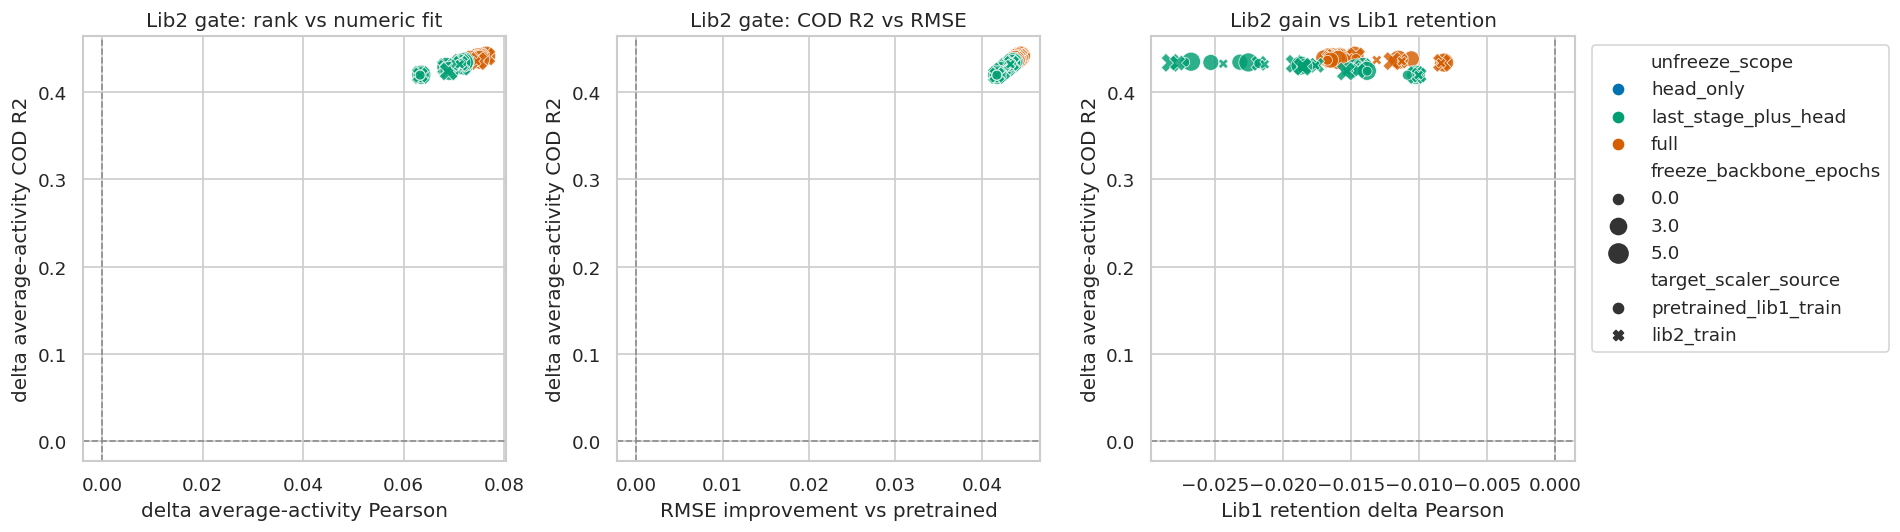

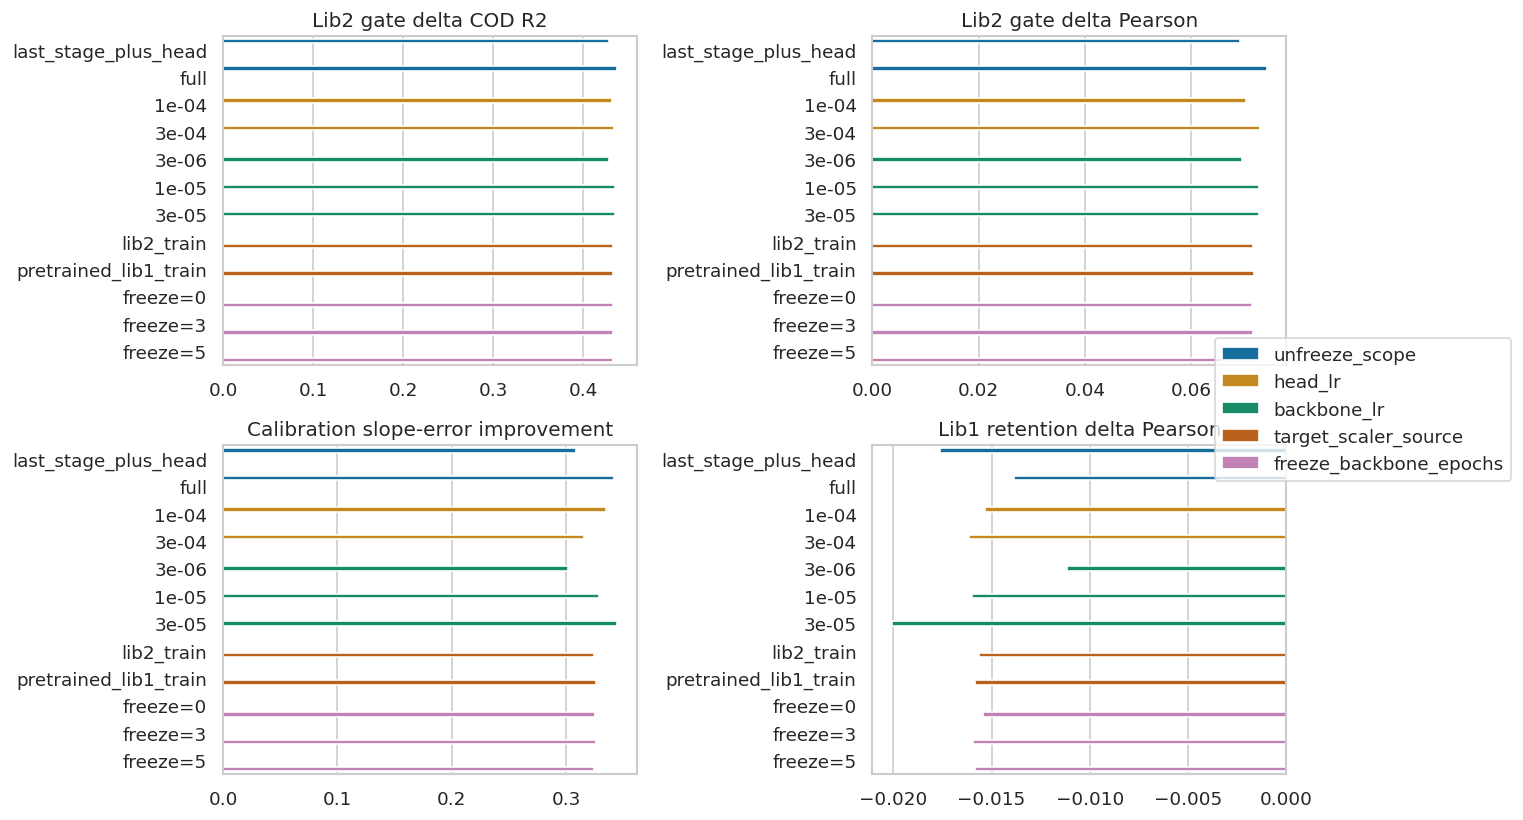

In [9]:
FACTOR_COLS = ["unfreeze_scope", "head_lr", "backbone_lr", "target_scaler_source", "freeze_backbone_epochs"]
FACTOR_METRIC_COLS = [
    "lib2_gate_delta_cod_r2_mean",
    "lib2_gate_rmse_improvement_mean",
    "lib2_gate_delta_pearson_mean",
    "lib2_gate_delta_spearman_mean",
    "lib2_gate_cal_slope_err_improvement_mean",
    "lib1_delta_pearson_mean",
    "lib1_delta_cod_r2_mean",
    "delta_inhouse_spearman_vs_pretrained_mean",
]

factor_frames = []
for factor in FACTOR_COLS:
    grouped = (
        hpo_multimetric.groupby(factor, observed=True)
        .agg(
            n_configs=("config_label", "size"),
            **{metric: (metric, "mean") for metric in FACTOR_METRIC_COLS},
        )
        .reset_index()
        .rename(columns={factor: "value"})
    )
    grouped.insert(0, "factor", factor)
    factor_frames.append(grouped)

factor_effects = pd.concat(factor_frames, ignore_index=True, sort=False)
factor_effects["value_label"] = factor_effects.apply(
    lambda row: lr_label(row["value"]) if row["factor"] in {"head_lr", "backbone_lr"} else (
        f"freeze={int(row['value'])}" if row["factor"] == "freeze_backbone_epochs" and pd.notna(row["value"]) else str(row["value"])
    ),
    axis=1,
)
factor_effects.to_csv(PLOT_DIR / "phase2_v2_hpo_factor_effects_multimetric.csv", index=False)

display(Markdown("Mean multi-metric effects by HPO factor. Positive deltas/improvements are better except Lib1 deltas, where values below zero are retention cost."))
display(factor_effects[["factor", "value_label", "n_configs", *FACTOR_METRIC_COLS]].round(5))

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))
scatter_kws = dict(
    data=hpo_multimetric,
    hue="unfreeze_scope",
    style="target_scaler_source",
    size="freeze_backbone_epochs",
    palette=SCOPE_PALETTE,
    sizes=(35, 130),
    alpha=0.82,
)

sns.scatterplot(
    x="lib2_gate_delta_pearson_mean",
    y="lib2_gate_delta_cod_r2_mean",
    ax=axes[0],
    **scatter_kws,
)
axes[0].axhline(0, color="0.55", linestyle="--", linewidth=1.0)
axes[0].axvline(0, color="0.55", linestyle="--", linewidth=1.0)
axes[0].set_title("Lib2 gate: rank vs numeric fit")
axes[0].set_xlabel("delta average-activity Pearson")
axes[0].set_ylabel("delta average-activity COD R2")

sns.scatterplot(
    x="lib2_gate_rmse_improvement_mean",
    y="lib2_gate_delta_cod_r2_mean",
    ax=axes[1],
    **scatter_kws,
)
axes[1].axhline(0, color="0.55", linestyle="--", linewidth=1.0)
axes[1].axvline(0, color="0.55", linestyle="--", linewidth=1.0)
axes[1].set_title("Lib2 gate: COD R2 vs RMSE")
axes[1].set_xlabel("RMSE improvement vs pretrained")
axes[1].set_ylabel("delta average-activity COD R2")

sns.scatterplot(
    x="lib1_delta_pearson_mean",
    y="lib2_gate_delta_cod_r2_mean",
    ax=axes[2],
    **scatter_kws,
)
axes[2].axhline(0, color="0.55", linestyle="--", linewidth=1.0)
axes[2].axvline(0, color="0.55", linestyle="--", linewidth=1.0)
axes[2].set_title("Lib2 gain vs Lib1 retention")
axes[2].set_xlabel("Lib1 retention delta Pearson")
axes[2].set_ylabel("delta average-activity COD R2")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

for ax in axes[:2]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

plt.tight_layout()
plt.savefig(PLOT_DIR / "phase2_v2_hpo_multimetric_tradeoffs.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.0))
bar_metrics = [
    ("lib2_gate_delta_cod_r2_mean", "Lib2 gate delta COD R2"),
    ("lib2_gate_delta_pearson_mean", "Lib2 gate delta Pearson"),
    ("lib2_gate_cal_slope_err_improvement_mean", "Calibration slope-error improvement"),
    ("lib1_delta_pearson_mean", "Lib1 retention delta Pearson"),
]
for ax, (metric, title) in zip(axes.ravel(), bar_metrics):
    sns.barplot(data=factor_effects, y="value_label", x=metric, hue="factor", ax=ax)
    ax.axvline(0, color="0.4", linestyle="--", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.legend_.remove()
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig(PLOT_DIR / "phase2_v2_hpo_factor_effects_multimetric.png", bbox_inches="tight")
plt.show()



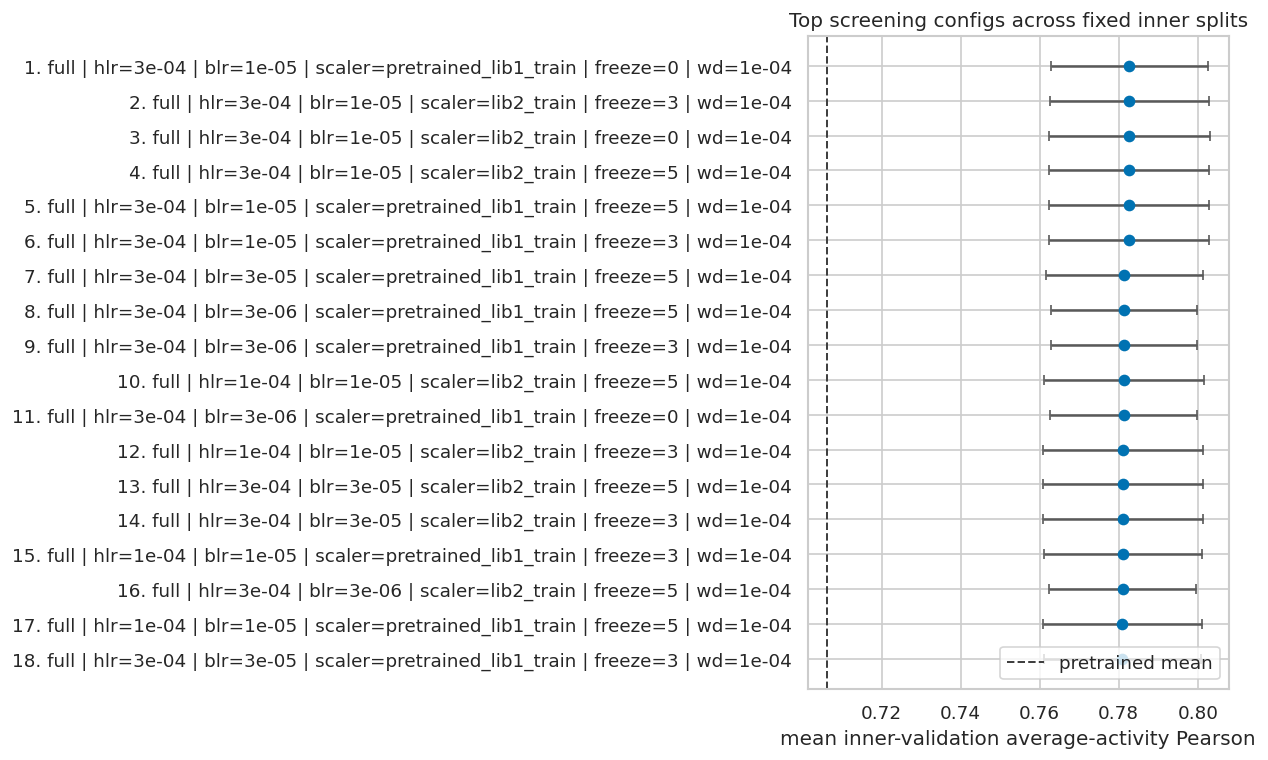

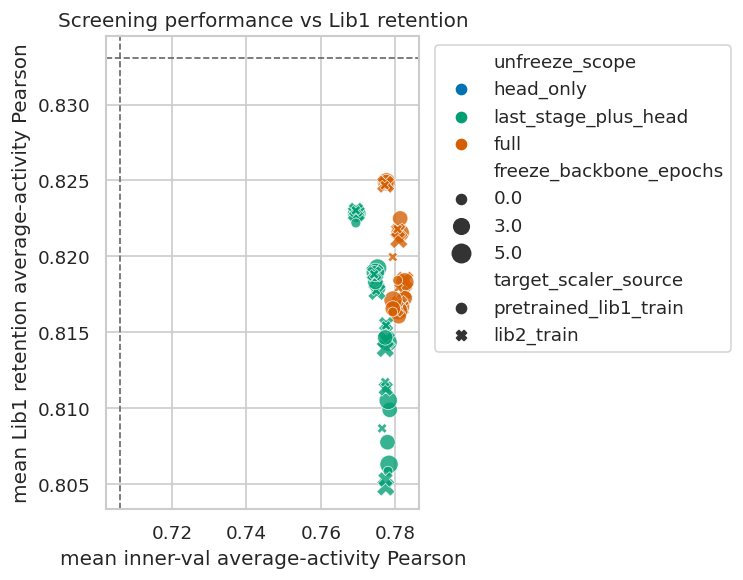

In [10]:
plot_df = leaderboard.head(18).copy()
plot_df["rank_label"] = plot_df["screening_rank"].astype(str) + ". " + plot_df["config_label"]
fig, ax = plt.subplots(figsize=(10.5, 6.5))
ax.errorbar(
    x=plot_df["inner_val_avg_r_mean"],
    y=np.arange(len(plot_df)),
    xerr=plot_df["inner_val_avg_r_se"],
    fmt="o",
    color="#0072B2",
    ecolor="0.35",
    capsize=3,
)
ax.axvline(baseline_inner["average_activity_pearson"].mean(), color="0.25", linestyle="--", linewidth=1.2, label="pretrained mean")
ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(plot_df["rank_label"])
ax.invert_yaxis()
ax.set_xlabel("mean inner-validation average-activity Pearson")
ax.set_ylabel("")
ax.set_title("Top screening configs across fixed inner splits")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "phase2_v2_screening_top_configs.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 5.0))
sns.scatterplot(
    data=leaderboard,
    x="inner_val_avg_r_mean",
    y="lib1_retention_avg_r_mean",
    hue="unfreeze_scope",
    style="target_scaler_source",
    size="freeze_backbone_epochs",
    palette=SCOPE_PALETTE,
    sizes=(35, 120),
    alpha=0.78,
    ax=ax,
)
ax.axvline(baseline_inner["average_activity_pearson"].mean(), color="0.4", linestyle="--", linewidth=1.0)
ax.axhline(baseline_lib1["average_activity_pearson"].mean(), color="0.4", linestyle="--", linewidth=1.0)
ax.set_title("Screening performance vs Lib1 retention")
ax.set_xlabel("mean inner-val average-activity Pearson")
ax.set_ylabel("mean Lib1 retention average-activity Pearson")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOT_DIR / "phase2_v2_screening_vs_lib1_retention.png", bbox_inches="tight")
plt.show()

## Early Stopping and Fit Diagnostics

Early-stop summary for the top screening configs.

,screening_rank,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,n_split_ids,best_epoch_mean,best_epoch_min,best_epoch_max,best_monitor_mean,best_monitor_se,n_selected_last_epoch
63,1,full,0.0003,0.0,pretrained_lib1_train,0,0.0001,3,138.3333,96,181,0.7827,0.0199,0
61,2,full,0.0003,0.0,lib2_train,3,0.0001,3,144.3333,96,181,0.7827,0.0201,0
60,3,full,0.0003,0.0,lib2_train,0,0.0001,3,135.6667,96,173,0.7827,0.0204,0
62,4,full,0.0003,0.0,lib2_train,5,0.0001,3,138.3333,96,181,0.7826,0.0202,0
65,5,full,0.0003,0.0,pretrained_lib1_train,5,0.0001,3,134.6667,96,173,0.7826,0.0201,0
64,6,full,0.0003,0.0,pretrained_lib1_train,3,0.0001,3,141.6667,96,173,0.7825,0.0202,0
71,7,full,0.0003,0.0,pretrained_lib1_train,5,0.0001,3,65.6667,59,72,0.7814,0.0198,0
59,8,full,0.0003,0.0,pretrained_lib1_train,5,0.0001,3,188.6667,172,197,0.7813,0.0186,0
58,9,full,0.0003,0.0,pretrained_lib1_train,3,0.0001,3,183.0000,165,197,0.7813,0.0185,0
44,10,full,0.0001,0.0,lib2_train,5,0.0001,3,170.6667,156,181,0.7813,0.0202,0


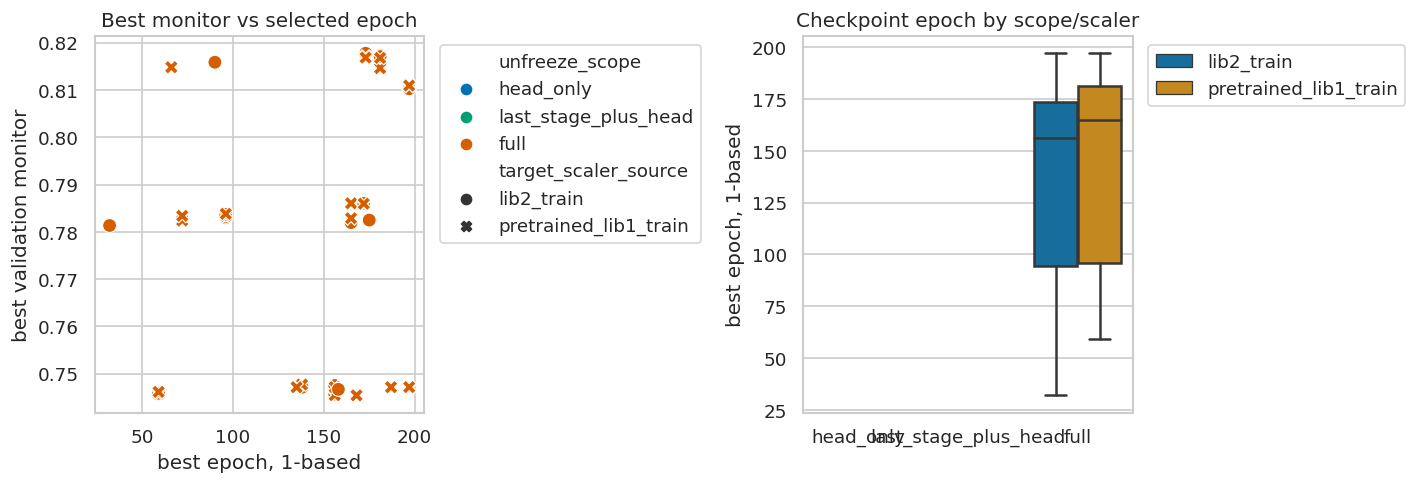

In [11]:
if fit_info.empty:
    display(Markdown("No fit_info.json records found."))
else:
    early = fit_info.copy()
    early["best_epoch_1based"] = pd.to_numeric(early["best_epoch"], errors="coerce") + 1
    early["max_epochs"] = pd.to_numeric(early["max_epochs"], errors="coerce")
    early["selected_last_epoch"] = early["best_epoch"].ge(early["max_epochs"] - 1)

    early_summary = (
        early.groupby(CONFIG_COLS, observed=True)
        .agg(
            n_split_ids=("split_id", "nunique"),
            best_epoch_mean=("best_epoch_1based", "mean"),
            best_epoch_min=("best_epoch_1based", "min"),
            best_epoch_max=("best_epoch_1based", "max"),
            best_monitor_mean=("best_monitor_value", "mean"),
            best_monitor_se=("best_monitor_value", standard_error),
            n_selected_last_epoch=("selected_last_epoch", "sum"),
        )
        .reset_index()
    )
    early_summary = add_common_columns(early_summary).merge(
        leaderboard[[*CONFIG_COLS, "screening_rank", "inner_val_avg_r_mean"]],
        on=CONFIG_COLS,
        how="left",
    ).sort_values("screening_rank")

    display(Markdown("Early-stop summary for the top screening configs."))
    display(early_summary[["screening_rank", *CONFIG_COLS, "n_split_ids", "best_epoch_mean", "best_epoch_min", "best_epoch_max", "best_monitor_mean", "best_monitor_se", "n_selected_last_epoch"]].head(25).round(4))

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
    plot_early = early.merge(leaderboard[[*CONFIG_COLS, "screening_rank"]], on=CONFIG_COLS, how="left")
    plot_early = plot_early[plot_early["screening_rank"].le(18)].copy()
    sns.scatterplot(
        data=plot_early,
        x="best_epoch_1based",
        y="best_monitor_value",
        hue="unfreeze_scope",
        style="target_scaler_source",
        palette=SCOPE_PALETTE,
        s=70,
        ax=axes[0],
    )
    axes[0].set_title("Best monitor vs selected epoch")
    axes[0].set_xlabel("best epoch, 1-based")
    axes[0].set_ylabel("best validation monitor")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.boxplot(
        data=plot_early,
        x="unfreeze_scope",
        y="best_epoch_1based",
        hue="target_scaler_source",
        ax=axes[1],
    )
    axes[1].set_title("Checkpoint epoch by scope/scaler")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("best epoch, 1-based")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "phase2_v2_early_stopping_diagnostics.png", bbox_inches="tight")
    plt.show()

## Lib1 Retention Scorecard

In [12]:
def config_match(frame: pd.DataFrame, config: dict) -> pd.Series:
    mask = pd.Series(True, index=frame.index)
    for col in CONFIG_COLS:
        if col not in frame.columns:
            continue
        if pd.api.types.is_numeric_dtype(frame[col]):
            mask &= np.isclose(pd.to_numeric(frame[col], errors="coerce"), float(config[col]))
        else:
            mask &= frame[col].astype(str).eq(str(config[col]))
    return mask

selected_summary = summary.loc[summary["model_family"].eq("finetuned") & config_match(summary, selected_config)].copy()
score_rows = []
for split in SCREENING_SPLITS:
    selected_split = selected_summary.loc[selected_summary["split"].eq(split)]
    baseline_split = summary.loc[(summary["model_label"].eq(BASELINE_LABEL)) & (summary["split"].eq(split))].drop_duplicates(["split_id", "model_label"])
    if selected_split.empty or baseline_split.empty:
        continue
    score_rows.append({
        "split": split,
        "selected avg r mean": selected_split["average_activity_pearson"].mean(),
        "selected avg r min": selected_split["average_activity_pearson"].min(),
        "pretrained avg r mean": baseline_split["average_activity_pearson"].mean(),
        "delta avg r mean": selected_split["average_activity_pearson"].mean() - baseline_split["average_activity_pearson"].mean(),
        "selected mean-head r mean": selected_split["mean_per_head_pearson"].mean(),
        "pretrained mean-head r mean": baseline_split["mean_per_head_pearson"].mean(),
        "delta mean-head r mean": selected_split["mean_per_head_pearson"].mean() - baseline_split["mean_per_head_pearson"].mean(),
        "selected avg RMSE mean": selected_split["average_activity_rmse"].mean(),
        "pretrained avg RMSE mean": baseline_split["average_activity_rmse"].mean(),
    })
scorecard = pd.DataFrame(score_rows)
display(scorecard.round(5))
scorecard.to_csv(PLOT_DIR / "phase2_v2_selected_config_scorecard.csv", index=False)

,split,selected avg r mean,selected avg r min,pretrained avg r mean,delta avg r mean,selected mean-head r mean,pretrained mean-head r mean,delta mean-head r mean,selected avg RMSE mean,pretrained avg RMSE mean
0,lib2_inner_val,0.78271,0.74770,0.70617,0.07653,0.61515,0.54308,0.07206,0.09585,0.14030
1,lib1_test_retention,0.81842,0.81697,0.83309,-0.01467,0.73504,0.75496,-0.01992,0.09512,0.08932


## Per-Head Metrics

,split,head_label,n_split_ids,pearson_mean,baseline_pearson_mean,delta_pearson,cod_r2_mean,baseline_cod_r2_mean,delta_cod_r2,rmse_mean
0,lib1_test_retention,c1 MDA-MB-231,3,0.76498,0.78322,-0.01824,0.45942,0.60849,-0.14907,0.12023
1,lib1_test_retention,c2 HepG2,3,0.79731,0.80989,-0.01258,0.61816,0.64902,-0.03086,0.07399
2,lib1_test_retention,c4 Jurkat,3,0.63361,0.64206,-0.00845,0.37943,0.39768,-0.01825,0.14860
3,lib1_test_retention,c6 SW480,3,0.74108,0.79120,-0.05012,0.48108,0.62290,-0.14182,0.15141
4,lib1_test_retention,c17 NALM6,3,0.73821,0.74841,-0.01021,0.53229,0.55341,-0.02111,0.15211
5,lib2_inner_val,c1 MDA-MB-231,3,0.62406,0.57930,0.04476,0.38813,-0.17374,0.56187,0.11231
6,lib2_inner_val,c2 HepG2,3,0.61523,0.54892,0.06631,0.37745,0.22852,0.14892,0.11926
7,lib2_inner_val,c4 Jurkat,3,0.66024,0.55303,0.10721,0.43433,0.22756,0.20677,0.18940
8,lib2_inner_val,c6 SW480,3,0.48379,0.40066,0.08313,0.23357,-0.22901,0.46258,0.20412
9,lib2_inner_val,c17 NALM6,3,0.69241,0.63350,0.05891,0.47650,0.24734,0.22915,0.18775


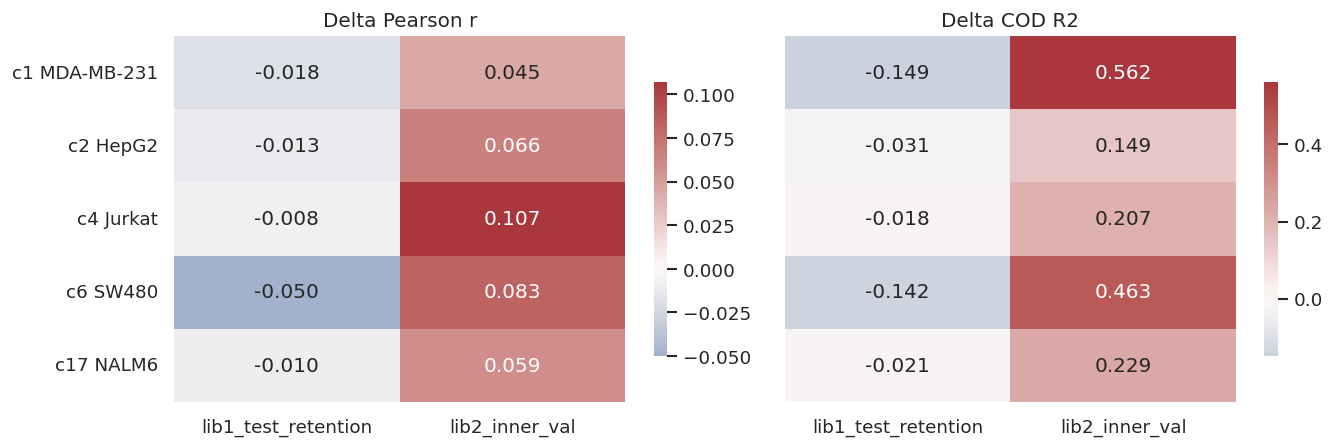

In [13]:
selected_per_head = per_head.loc[per_head["model_family"].eq("finetuned") & config_match(per_head, selected_config)].copy()
baseline_per_head = per_head.loc[per_head["model_label"].eq(BASELINE_LABEL)].drop_duplicates(["split_id", "split", "head", "model_label"]).copy()

selected_head_agg = (
    selected_per_head.groupby(["split", "head", "head_label"], observed=True)
    .agg(
        n_split_ids=("split_id", "nunique"),
        pearson_mean=("pearson", "mean"),
        pearson_se=("pearson", standard_error),
        spearman_mean=("spearman", "mean"),
        cod_r2_mean=("cod_r2", "mean"),
        rmse_mean=("rmse", "mean"),
    )
    .reset_index()
)
baseline_head_agg = (
    baseline_per_head.groupby(["split", "head", "head_label"], observed=True)
    .agg(
        baseline_pearson_mean=("pearson", "mean"),
        baseline_spearman_mean=("spearman", "mean"),
        baseline_cod_r2_mean=("cod_r2", "mean"),
        baseline_rmse_mean=("rmse", "mean"),
    )
    .reset_index()
)
head_compare = selected_head_agg.merge(baseline_head_agg, on=["split", "head", "head_label"], how="left")
head_compare["delta_pearson"] = head_compare["pearson_mean"] - head_compare["baseline_pearson_mean"]
head_compare["delta_cod_r2"] = head_compare["cod_r2_mean"] - head_compare["baseline_cod_r2_mean"]

display(head_compare.sort_values(["split", "head"])[["split", "head_label", "n_split_ids", "pearson_mean", "baseline_pearson_mean", "delta_pearson", "cod_r2_mean", "baseline_cod_r2_mean", "delta_cod_r2", "rmse_mean"]].round(5))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for ax, value, title in zip(axes, ["delta_pearson", "delta_cod_r2"], ["Delta Pearson r", "Delta COD R2"]):
    heat = head_compare.pivot(index="head_label", columns="split", values=value).reindex([HEAD_LABELS[h] for h in HEAD_ORDER])
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="vlag", center=0, ax=ax, cbar_kws={"shrink": 0.75})
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "phase2_v2_selected_config_per_head_delta_heatmap.png", bbox_inches="tight")
plt.show()

## Per-Epoch Diagnostics for the Selected Config

In [ ]:
selected_epoch = epoch_diag.loc[config_match(epoch_diag, selected_config)].copy()
if selected_epoch.empty:
    display(Markdown("No per-epoch diagnostics matched the selected config."))
else:
    present_epoch_splits = [split for split in EPOCH_SPLIT_ORDER if split in set(selected_epoch["split"].astype(str))]
    selected_epoch["split"] = pd.Categorical(selected_epoch["split"], categories=present_epoch_splits, ordered=True)
    mean_epoch = (
        selected_epoch.groupby(["epoch", "split", "split_id"], observed=True)
        .agg(
            mean_pearson=("pearson", "mean"),
            mean_spearman=("spearman", "mean"),
            mean_cod_r2=("cod_r2", "mean"),
            mean_loss=("loss", "mean"),
            n_heads=("head", "nunique"),
        )
        .reset_index()
    )
    display(Markdown("Selected-config fit records."))
    display(fit_info.loc[config_match(fit_info, selected_config), ["split_id", "training_seed", "best_epoch", "best_monitor_value", "monitor_metric", "max_epochs", "patience"]].sort_values("split_id").round(5))
    epoch_split_counts = (
        selected_epoch.groupby("split", observed=True)
        .agg(n_rows=("epoch", "size"), n_epochs=("epoch", "nunique"), n_split_ids=("split_id", "nunique"))
        .reset_index()
    )
    display(Markdown("Per-epoch diagnostic splits present. Screening runs do not log the heldout Lib2 final-test split per epoch."))
    display(epoch_split_counts)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
    for ax, metric, ylabel in [
        (axes[0], "mean_pearson", "mean per-head Pearson r"),
        (axes[1], "mean_loss", "mean loss"),
    ]:
        sns.lineplot(
            data=mean_epoch,
            x="epoch",
            y=metric,
            hue="split",
            hue_order=present_epoch_splits,
            style="split_id",
            palette=SPLIT_PALETTE,
            ax=ax,
        )
        ax.set_title(ylabel)
        ax.set_xlabel("epoch")
        ax.set_ylabel(ylabel)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.suptitle("Selected config diagnostics across inner splits", y=1.02)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "phase2_v2_selected_config_epoch_diagnostics.png", bbox_inches="tight")
    plt.show()

## In-House FivePrime Proxy Readout

This is diagnostic only for screening. It is useful as an external sanity check, not as the Lib2 final-test answer.

Average-head predictor on high-quality FivePrime rows.

,model,spearman_mean,pearson_mean,cod_r2_mean
0,pretrained baseline,0.22673,0.17946,-0.17233
1,selected screening config,0.20392,0.16414,-0.12301


Top configs by FivePrime proxy Spearman, diagnostic only.

,screening_rank,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,n_split_ids,spearman_mean,spearman_se,pearson_mean,cod_r2_mean,inner_val_avg_r_mean,lib1_retention_avg_r_mean
13,49,last_stage_plus_head,0.0001,0.00003,lib2_train,3.0,0.0001,3,0.21749,0.00169,0.17164,-0.12511,0.77740,0.80530
14,46,last_stage_plus_head,0.0001,0.00003,lib2_train,5.0,0.0001,3,0.21658,0.00236,0.17046,-0.12630,0.77749,0.80480
15,35,last_stage_plus_head,0.0001,0.00003,pretrained_lib1_train,0.0,0.0001,3,0.21576,0.00215,0.17020,-0.12331,0.77808,0.80584
16,36,last_stage_plus_head,0.0001,0.00003,pretrained_lib1_train,3.0,0.0001,3,0.21536,0.00229,0.17026,-0.12339,0.77794,0.80775
20,58,last_stage_plus_head,0.0003,0.00000,lib2_train,5.0,0.0001,3,0.21509,0.00043,0.17310,-0.10447,0.77511,0.81769
17,32,last_stage_plus_head,0.0001,0.00003,pretrained_lib1_train,5.0,0.0001,3,0.21505,0.00244,0.16901,-0.12453,0.77835,0.80630
18,60,last_stage_plus_head,0.0003,0.00000,lib2_train,0.0,0.0001,3,0.21502,0.00063,0.17257,-0.10514,0.77488,0.81774
21,55,last_stage_plus_head,0.0003,0.00000,pretrained_lib1_train,0.0,0.0001,3,0.21496,0.00089,0.17389,-0.10313,0.77543,0.81924
22,56,last_stage_plus_head,0.0003,0.00000,pretrained_lib1_train,3.0,0.0001,3,0.21496,0.00149,0.17265,-0.10894,0.77538,0.81790
0,72,last_stage_plus_head,0.0001,0.00000,lib2_train,0.0,0.0001,3,0.21487,0.00109,0.17300,-0.11450,0.76941,0.82303


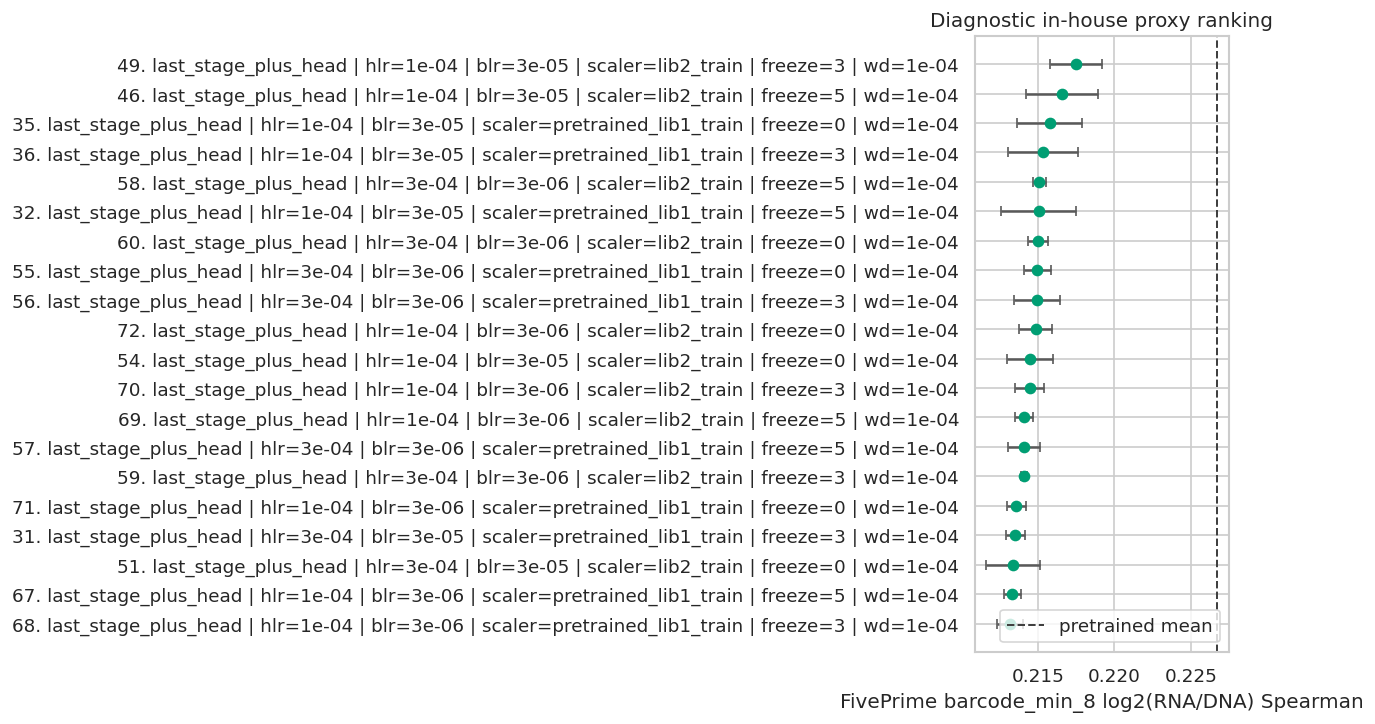

In [15]:
inhouse_log2_hq = inhouse.loc[
    inhouse["target"].eq("log2_RNA_DNA")
    & inhouse["subset"].eq("barcode_min_8")
].copy()

avg_proxy = inhouse_log2_hq.loc[inhouse_log2_hq["predictor"].eq("pred_average_activity")].copy()
inhouse_config = (
    avg_proxy.loc[avg_proxy["model_family"].eq("finetuned")]
    .groupby(CONFIG_COLS, observed=True)
    .agg(
        n_split_ids=("split_id", "nunique"),
        spearman_mean=("spearman", "mean"),
        spearman_se=("spearman", standard_error),
        pearson_mean=("pearson", "mean"),
        cod_r2_mean=("cod_r2", "mean"),
        rmse_mean=("rmse", "mean"),
    )
    .reset_index()
)
inhouse_config = add_common_columns(inhouse_config).merge(
    leaderboard[[*CONFIG_COLS, "screening_rank", "inner_val_avg_r_mean", "lib1_retention_avg_r_mean"]],
    on=CONFIG_COLS,
    how="left",
).sort_values("spearman_mean", ascending=False)

baseline_proxy = avg_proxy.loc[avg_proxy["model_label"].eq(BASELINE_LABEL)].drop_duplicates(["split_id", "predictor"])
selected_proxy_rows = avg_proxy.loc[avg_proxy["model_family"].eq("finetuned") & config_match(avg_proxy, selected_config)]

proxy_summary = pd.DataFrame([
    {
        "model": "pretrained baseline",
        "spearman_mean": baseline_proxy["spearman"].mean(),
        "pearson_mean": baseline_proxy["pearson"].mean(),
        "cod_r2_mean": baseline_proxy["cod_r2"].mean(),
    },
    {
        "model": "selected screening config",
        "spearman_mean": selected_proxy_rows["spearman"].mean(),
        "pearson_mean": selected_proxy_rows["pearson"].mean(),
        "cod_r2_mean": selected_proxy_rows["cod_r2"].mean(),
    },
])

display(Markdown("Average-head predictor on high-quality FivePrime rows."))
display(proxy_summary.round(5))
display(Markdown("Top configs by FivePrime proxy Spearman, diagnostic only."))
display(inhouse_config[["screening_rank", *CONFIG_COLS, "n_split_ids", "spearman_mean", "spearman_se", "pearson_mean", "cod_r2_mean", "inner_val_avg_r_mean", "lib1_retention_avg_r_mean"]].head(20).round(5))

plot_proxy = inhouse_config.head(20).copy()
plot_proxy["rank_label"] = plot_proxy["screening_rank"].map(lambda x: "NA" if pd.isna(x) else str(int(x))) + ". " + plot_proxy["config_label"]
fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.errorbar(
    x=plot_proxy["spearman_mean"],
    y=np.arange(len(plot_proxy)),
    xerr=plot_proxy["spearman_se"],
    fmt="o",
    color="#009E73",
    ecolor="0.35",
    capsize=3,
)
ax.axvline(baseline_proxy["spearman"].mean(), color="0.25", linestyle="--", linewidth=1.2, label="pretrained mean")
ax.set_yticks(np.arange(len(plot_proxy)))
ax.set_yticklabels(plot_proxy["rank_label"])
ax.invert_yaxis()
ax.set_xlabel("FivePrime barcode_min_8 log2(RNA/DNA) Spearman")
ax.set_ylabel("")
ax.set_title("Diagnostic in-house proxy ranking")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "phase2_v2_inhouse_proxy_top_configs.png", bbox_inches="tight")
plt.show()

In [ ]:
INHOUSE_PROXY_METRIC_ALIASES = {
    "spearman": "spearman",
    "spearman_r": "spearman",
    "pearson": "pearson",
    "pearson_r": "pearson",
    "r": "pearson",
    "cod": "cod_r2",
    "cod_r2": "cod_r2",
    "r2_cod": "cod_r2",
}

INHOUSE_PROXY_METRIC_LABELS = {
    "spearman": "Spearman R",
    "pearson": "Pearson R",
    "cod_r2": "COD R2",
}


def display_inhouse_proxy_metric(metric="pearson", top_n=20, plot=True, save=True):
    metric_key = str(metric).lower().replace("-", "_").replace(" ", "_")
    metric_col = INHOUSE_PROXY_METRIC_ALIASES.get(metric_key)
    if metric_col is None:
        valid = ", ".join(sorted(INHOUSE_PROXY_METRIC_ALIASES))
        raise ValueError(f"Unknown metric {metric!r}. Valid aliases: {valid}")

    metric_label = INHOUSE_PROXY_METRIC_LABELS[metric_col]
    mean_col = f"{metric_col}_mean"
    se_col = f"{metric_col}_se"
    delta_col = f"delta_{metric_col}_vs_pretrained_mean"

    agg_spec = {
        "n_split_ids": ("split_id", "nunique"),
        "spearman_mean": ("spearman", "mean"),
        "pearson_mean": ("pearson", "mean"),
        "cod_r2_mean": ("cod_r2", "mean"),
        "rmse_mean": ("rmse", "mean"),
        se_col: (metric_col, standard_error),
    }
    metric_config = (
        avg_proxy.loc[avg_proxy["model_family"].eq("finetuned")]
        .groupby(CONFIG_COLS, observed=True)
        .agg(**agg_spec)
        .reset_index()
    )
    metric_config = add_common_columns(metric_config).merge(
        leaderboard[[*CONFIG_COLS, "screening_rank", "inner_val_avg_r_mean", "lib1_retention_avg_r_mean"]],
        on=CONFIG_COLS,
        how="left",
    )

    baseline_rows = avg_proxy.loc[avg_proxy["model_label"].eq(BASELINE_LABEL)].drop_duplicates(["split_id", "predictor"])
    selected_rows = avg_proxy.loc[
        avg_proxy["model_family"].eq("finetuned")
        & config_match(avg_proxy, selected_config)
    ]
    baseline_metric = baseline_rows[metric_col].mean()
    metric_config[delta_col] = metric_config[mean_col] - baseline_metric
    metric_config["is_selected_screening_config"] = config_match(metric_config, selected_config)
    metric_config = metric_config.sort_values(mean_col, ascending=False).reset_index(drop=True)

    change_summary = pd.DataFrame([
        {
            "model": "pretrained baseline",
            "metric": metric_label,
            mean_col: baseline_metric,
            delta_col: 0.0,
            "spearman_mean": baseline_rows["spearman"].mean(),
            "pearson_mean": baseline_rows["pearson"].mean(),
            "cod_r2_mean": baseline_rows["cod_r2"].mean(),
            "rmse_mean": baseline_rows["rmse"].mean(),
        },
        {
            "model": "selected screening config",
            "metric": metric_label,
            mean_col: selected_rows[metric_col].mean(),
            delta_col: selected_rows[metric_col].mean() - baseline_metric,
            "spearman_mean": selected_rows["spearman"].mean(),
            "pearson_mean": selected_rows["pearson"].mean(),
            "cod_r2_mean": selected_rows["cod_r2"].mean(),
            "rmse_mean": selected_rows["rmse"].mean(),
        },
    ])

    display(Markdown(f"Average-head predictor on high-quality FivePrime rows: **{metric_label} change**."))
    display(change_summary.round(5))

    display_cols = [
        "screening_rank",
        *CONFIG_COLS,
        "n_split_ids",
        mean_col,
        se_col,
        delta_col,
        "spearman_mean",
        "pearson_mean",
        "cod_r2_mean",
        "rmse_mean",
        "inner_val_avg_r_mean",
        "lib1_retention_avg_r_mean",
        "is_selected_screening_config",
    ]
    display_cols = list(dict.fromkeys([col for col in display_cols if col in metric_config.columns]))
    display(Markdown(f"Top configs by FivePrime proxy {metric_label}, diagnostic only."))
    display(metric_config[display_cols].head(top_n).round(5))

    if plot:
        plot_metric = metric_config.head(top_n).copy()
        plot_metric["rank_label"] = (
            plot_metric["screening_rank"].map(lambda x: "NA" if pd.isna(x) else str(int(x)))
            + ". "
            + plot_metric["config_label"]
        )
        fig, ax = plt.subplots(figsize=(10.5, 6.2))
        ax.errorbar(
            x=plot_metric[mean_col],
            y=np.arange(len(plot_metric)),
            xerr=plot_metric[se_col],
            fmt="o",
            color="#0072B2",
            ecolor="0.35",
            capsize=3,
        )
        ax.axvline(baseline_metric, color="0.25", linestyle="--", linewidth=1.2, label="pretrained mean")
        ax.set_yticks(np.arange(len(plot_metric)))
        ax.set_yticklabels(plot_metric["rank_label"])
        ax.invert_yaxis()
        ax.set_xlabel(f"FivePrime barcode_min_8 log2(RNA/DNA) {metric_label}")
        ax.set_ylabel("")
        ax.set_title(f"Diagnostic in-house proxy ranking by {metric_label}")
        ax.legend(loc="lower right")
        plt.tight_layout()
        if save:
            plot_path = PLOT_DIR / f"phase2_v2_inhouse_proxy_top_configs_{metric_col}.png"
            plt.savefig(plot_path, bbox_inches="tight")
        plt.show()

    return metric_config


pearson_proxy_config = display_inhouse_proxy_metric("pearson", top_n=20)
cod_r2_proxy_config = display_inhouse_proxy_metric("cod_r2", top_n=20)


## Prediction-Level Scatter Checks

In [ ]:
def prediction_path_for(model_label: str, split_name: str, split_id=None, training_seed=None) -> Path:
    if split_id is None and "split_id" in selected_checkpoint:
        split_id = str(selected_checkpoint["split_id"])
    seed_glob = "*" if training_seed is None else str(int(training_seed))
    split_glob = "*" if split_id is None else split_id
    if model_label == BASELINE_LABEL:
        candidates = sorted(SWEEP_DIR.glob(f"per_job/*/{split_glob}/training_seed_{seed_glob}/predictions/{model_label}__{split_name}_predictions.csv"))
    else:
        candidates = sorted(SWEEP_DIR.glob(f"per_job/*/{split_glob}/training_seed_{seed_glob}/runs/*/predictions/{model_label}__{split_name}_predictions.csv"))
    if not candidates:
        raise FileNotFoundError((model_label, split_name, split_id, training_seed))
    return candidates[0]


def scatter_cod_r2(y_true, y_pred) -> float:
    true = pd.to_numeric(pd.Series(y_true), errors="coerce").to_numpy(dtype=float)
    pred = pd.to_numeric(pd.Series(y_pred), errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(true) & np.isfinite(pred)
    true = true[mask]
    pred = pred[mask]
    if len(true) < 2:
        return np.nan
    denom = float(np.sum((true - true.mean()) ** 2))
    if denom <= 0:
        return np.nan
    return float(1.0 - np.sum((true - pred) ** 2) / denom)


def plot_prediction_scatter(model_label: str, split_name: str, *, predictor: str, target: str, split_id=None, training_seed=None, min_barcodes=None):
    path = prediction_path_for(model_label, split_name, split_id=split_id, training_seed=training_seed)
    frame = pd.read_csv(path)
    if min_barcodes is not None and "number_of_barcodes" in frame.columns:
        frame = frame[pd.to_numeric(frame["number_of_barcodes"], errors="coerce").ge(min_barcodes)].copy()
    frame = frame[[target, predictor]].replace([np.inf, -np.inf], np.nan).dropna()
    r = frame[predictor].corr(frame[target], method="pearson")
    rho = frame[predictor].corr(frame[target], method="spearman")
    cod_r2 = scatter_cod_r2(frame[target], frame[predictor])
    fig, ax = plt.subplots(figsize=(4.8, 4.3))
    sns.regplot(
        data=frame,
        x=predictor,
        y=target,
        scatter_kws={"s": 12, "alpha": 0.35, "linewidth": 0},
        line_kws={"color": "black", "linewidth": 1.2},
        ax=ax,
    )
    title_label = model_label if model_label == BASELINE_LABEL else model_label.replace("finetuned_1mmy39ku__", "")
    ax.set_title(f"{title_label[:55]}\nr={r:.3f}, Spearman={rho:.3f}, COD R2={cod_r2:.3f}, n={len(frame)}")
    ax.set_xlabel(predictor)
    ax.set_ylabel(target)
    plt.tight_layout()
    safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", f"scatter_{split_name}_{model_label}_{predictor}_{target}")[:180]
    plt.savefig(PLOT_DIR / f"{safe}.png", bbox_inches="tight")
    plt.show()

print("Selected individual checkpoint for scatter:", selected_label)
print("split_id:", selected_split_id, "training_seed:", selected_training_seed)

plot_prediction_scatter(BASELINE_LABEL, "lib2_inner_val", predictor="pred_average_activity", target="true_average_activity", split_id=selected_split_id)
plot_prediction_scatter(selected_label, "lib2_inner_val", predictor="pred_average_activity", target="true_average_activity", split_id=selected_split_id, training_seed=selected_training_seed)
plot_prediction_scatter(BASELINE_LABEL, "inhouse_fiveprime", predictor="pred_average_activity", target="log2_RNA_DNA", split_id=selected_split_id, min_barcodes=8)
plot_prediction_scatter(selected_label, "inhouse_fiveprime", predictor="pred_average_activity", target="log2_RNA_DNA", split_id=selected_split_id, training_seed=selected_training_seed, min_barcodes=8)

## Final-Evaluation Gate

This section should remain empty after screening and confirmation. It only reports final-test metrics after a separate `STAGE=final_eval` run has been added to the same output root and recombined.

In [17]:
final_rows = summary.loc[summary["split"].eq("lib2_final_test")].copy()
if final_rows.empty:
    display(Markdown("No `lib2_final_test` rows found. That is expected for screening-only outputs."))
else:
    display(Markdown("Final-test rows detected. Confirm the config and selection rule were frozen before using these numbers."))
    display(final_rows.sort_values("average_activity_pearson", ascending=False).head(20).round(5))
    if not final_ranking.empty:
        display(Markdown("Combined final-test ranking."))
        display(final_ranking.head(20).round(5))

No `lib2_final_test` rows found. That is expected for screening-only outputs.

## Decision Notes

In [18]:
selected_row = leaderboard.iloc[0]
selected_proxy_summary = selected_proxy_rows.agg({"spearman": "mean", "pearson": "mean", "cod_r2": "mean"}) if not selected_proxy_rows.empty else pd.Series(dtype=float)
notes = pd.DataFrame([
    {
        "screening_rank": int(selected_row["screening_rank"]),
        "selected_scope": selected_row["unfreeze_scope"],
        "head_lr": selected_row["head_lr"],
        "backbone_lr": selected_row["backbone_lr"],
        "target_scaler_source": selected_row["target_scaler_source"],
        "freeze_backbone_epochs": selected_row["freeze_backbone_epochs"],
        "weight_decay": selected_row["weight_decay"],
        "inner_val_avg_r_mean": selected_row["inner_val_avg_r_mean"],
        "inner_val_avg_r_se": selected_row["inner_val_avg_r_se"],
        "inner_val_avg_r_min": selected_row["inner_val_avg_r_min"],
        "lib1_retention_avg_r_mean": selected_row["lib1_retention_avg_r_mean"],
        "delta_inner_val_avg_r_vs_pretrained_mean": selected_row["delta_inner_val_avg_r_vs_pretrained_mean"],
        "delta_lib1_retention_avg_r_vs_pretrained_mean": selected_row["delta_lib1_retention_avg_r_vs_pretrained_mean"],
        "inhouse_avg_head_spearman_mean": selected_proxy_summary.get("spearman", np.nan),
        "inhouse_avg_head_pearson_mean": selected_proxy_summary.get("pearson", np.nan),
        "selected_individual_checkpoint_for_scatter": selected_label,
        "final_test_status": "not_present" if final_rows.empty else "present",
    }
])

display(Markdown("Screening selection summary. Use this to choose confirmation finalists, not as final-test evidence."))
display(notes.round(5))
notes.to_csv(PLOT_DIR / "phase2_v2_screening_selection_summary.csv", index=False)

candidate_finalists = leaderboard.head(3).copy()
display(Markdown("Top three screening configs to consider for confirmation."))
display(candidate_finalists[["screening_rank", *CONFIG_COLS, "inner_val_avg_r_mean", "inner_val_avg_r_se", "inner_val_avg_r_min", "lib1_retention_avg_r_mean", "delta_lib1_retention_avg_r_vs_pretrained_mean"]].round(5))
candidate_finalists.to_csv(PLOT_DIR / "phase2_v2_screening_top3_confirmation_candidates.csv", index=False)

Screening selection summary. Use this to choose confirmation finalists, not as final-test evidence.

,screening_rank,selected_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,inner_val_avg_r_mean,inner_val_avg_r_se,inner_val_avg_r_min,lib1_retention_avg_r_mean,delta_inner_val_avg_r_vs_pretrained_mean,delta_lib1_retention_avg_r_vs_pretrained_mean,inhouse_avg_head_spearman_mean,inhouse_avg_head_pearson_mean,selected_individual_checkpoint_for_scatter,final_test_status
0,1,full,0.0003,0.00001,pretrained_lib1_train,0.0,0.0001,0.78271,0.01994,0.7477,0.81842,0.07653,-0.01467,0.20392,0.16414,finetuned_1mmy39ku__screening__inner0_seed_101...,not_present


Top three screening configs to consider for confirmation.

,screening_rank,unfreeze_scope,head_lr,backbone_lr,target_scaler_source,freeze_backbone_epochs,weight_decay,inner_val_avg_r_mean,inner_val_avg_r_se,inner_val_avg_r_min,lib1_retention_avg_r_mean,delta_lib1_retention_avg_r_vs_pretrained_mean
0,1,full,0.0003,0.00001,pretrained_lib1_train,0.0,0.0001,0.78271,0.01994,0.74770,0.81842,-0.01467
1,2,full,0.0003,0.00001,lib2_train,3.0,0.0001,0.78268,0.02015,0.74750,0.81763,-0.01545
2,3,full,0.0003,0.00001,lib2_train,0.0,0.0001,0.78265,0.02035,0.74724,0.81803,-0.01505
